In [61]:
import time
import warnings
from aci.components.precipitation_bis import PrecipitationComponent
from dask.diagnostics import ProgressBar   # ← progress bar helper

t0 = time.perf_counter()                   # start timer

# ── Instantiate component ────────────────────────────────────────────────

precipitation = PrecipitationComponent(

    precipitation_data_path="/Users/coralieroland/ACI-Python/data/required_data/precipitation",

    mask_path="/Users/coralieroland/ACI-Python/data/required_data/mask_BEL.nc"

)

# ── Calculate SPI (still lazy / dask) ─────────────────────────────────────
precipitation_index = precipitation.calculate_component(
    reference_period=("1961-01-01", "1990-12-31"),
    area=True
)

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ── Compute with progress bar ─────────────────────────────────────────────
with ProgressBar():
    precipitation_index_computed = precipitation_index.compute()

precipitation_index_cleaned = precipitation_index_computed.sel(
    time=slice("1961-01-01", None)
)

# ── Output ─────────────────────────────────────────────────
print("✅ Precipitation Index calculated successfully!\n")
print(precipitation_index)

# ── Save cleaned SPI ─────────────────────────────────────────────────────

output_path = "/Users/coralieroland/ACI-Python/data/composites/precipitation_index.nc"

print(f"Saving Precipitation Index to {output_path}…")

precipitation_index_cleaned.to_netcdf(output_path)

# ── Timer ────────────────────────────────────────────────────────────────
t1 = time.perf_counter()
print(f"\n⏱️  Total run time: {t1 - t0:.2f} seconds")


/Users/coralieroland/miniconda3/envs/aci-env/lib/python3.10/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 65 times more chunks
  return self.array[key]
/Users/coralieroland/miniconda3/envs/aci-env/lib/python3.10/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 65 times more chunks
  return self.array[key]


✅ Precipitation Index calculated successfully!

<xarray.DataArray 'tp' (time: 769, step: 24)> Size: 74kB
dask.array<mean_agg-aggregate, shape=(769, 24), dtype=float32, chunksize=(1, 24), chunktype=numpy.ndarray>
Coordinates:
    number   int64 8B 0
  * step     (step) timedelta64[ns] 192B 01:00:00 02:00:00 ... 1 days 00:00:00
    surface  float64 8B 0.0
  * time     (time) datetime64[ns] 6kB 1960-12-31 1961-01-31 ... 2024-12-31
Saving Precipitation Index to /Users/coralieroland/ACI-Python/data/composites/precipitation_index.nc…

⏱️  Total run time: 42.37 seconds


Plot saved as spi_bars_and_moving_avg_fullwindow.png


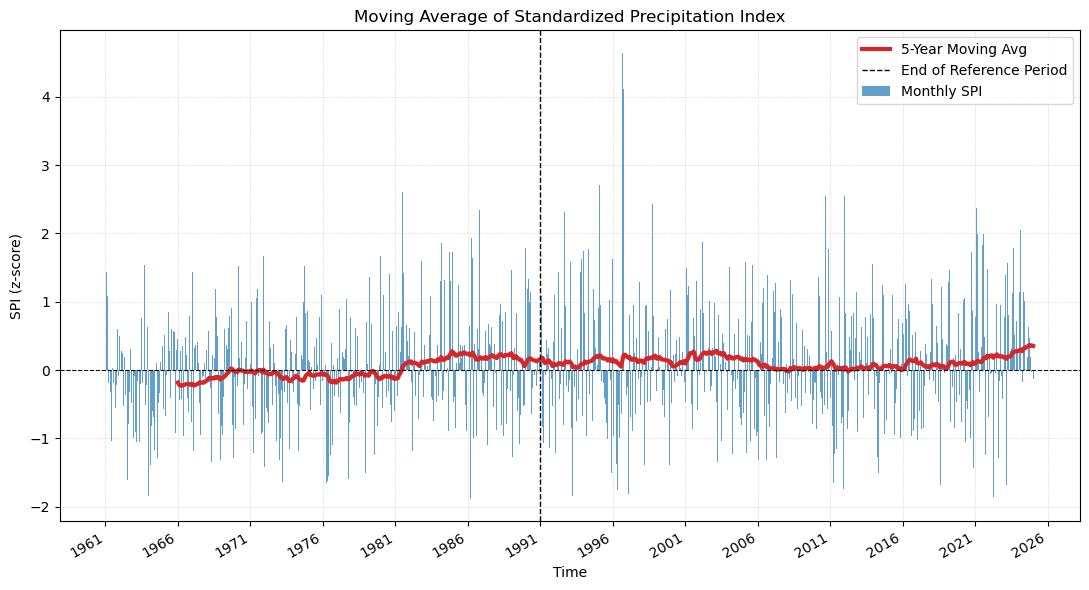

In [26]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── 1. Load cleaned SPI from disk ──────────────────────────────────────────
da = xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/precipitation_index.nc")

# ── 2. Collapse over 'step' → 1-D monthly SPI series ─────────────────────
monthly_spi = da.mean(dim="step")
spi_series = (
    monthly_spi
    .sel(time=slice("1961-01-01", None))
    .to_series()
    .dropna()
)

# ── 3. Compute right-aligned 60-month rolling mean with full-window only ──
rolling_60 = (
    spi_series
    .rolling(window=60, center=False, min_periods=60)
    .mean()
    .dropna()        # remove the first ~59 NaNs
)

# ── 4. Plot bars + moving average ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

# a) Monthly SPI bars (1961–2024)
ax.bar(
    spi_series.index,
    spi_series.values,
    width=25,
    color="tab:blue",
    alpha=0.7,
    label="Monthly SPI"
)

# b) 5-year moving average line (1966–2024)
ax.plot(
    rolling_60.index,
    rolling_60.values,
    color="tab:red",
    linewidth=3,
    label="5-Year Moving Avg"
)

# ── Add vertical line at end of reference period ──────────────────────────
import pandas as pd
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(ref_end, color="black", linestyle="--", linewidth=1, label="End of Reference Period")

# ── Cosmetics ─────────────────────────────────────────────────────────────
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Moving Average of Standardized Precipitation Index")
ax.set_xlabel("Time")
ax.set_ylabel("SPI (z-score)")
ax.grid(True, linestyle=":", linewidth=0.4)
ax.legend()

# ── Custom 5-year x-axis ticks ───────────────────────────────────────────
import datetime
years = list(range(1961, 2027, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.autofmt_xdate()
plt.tight_layout()

# ── 5. Save figure ───────────────────────────────────────────────────────
fig.savefig("spi_bars_and_moving_avg_fullwindow.png", dpi=300, bbox_inches="tight")
print("Plot saved as spi_bars_and_moving_avg_fullwindow.png")

plt.show()





In [30]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy import stats

# ── 1. Load cleaned SPI Index ───────────────────────────────────────────────
da = (
    xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/precipitation_index.nc")
      .sel(time=slice("1961-01-01", None))
)

# ── 2. Collapse over 'step' if present (for SPI it's already 1-D) ─────────
if "step" in da.dims:
    da = da.mean(dim="step")

# Force load into memory
da = da.compute()

# ── 3. Convert to pandas Series and drop NaNs ──────────────────────────────
ser   = da.to_series().dropna()
n_tot = ser.size

# ── 4. Descriptive statistics ─────────────────────────────────────────────
desc  = ser.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew  = ser.skew()
kurt  = ser.kurtosis()

# ── 5. Event counts ────────────────────────────────────────────────────────
#  moderate: 1σ < |SPI| ≤ 2σ
n_mod_pos = ((ser > 1) & (ser <= 2)).sum()
n_mod_neg = ((ser < -1) & (ser >= -2)).sum()
n_mod     = n_mod_pos + n_mod_neg

#  extreme: |SPI| > 2σ
n_extreme = ((ser > 2) | (ser < -2)).sum()

# ── 6. Linear trend (OLS) ─────────────────────────────────────────────────
years      = ser.index.year + (ser.index.dayofyear - 1) / 365.25
slope, intercept, r, p, _ = stats.linregress(years, ser.values)

# ── 7. Print results ─────────────────────────────────────────────────────
print("\n📊 Descriptive statistics for SPI_index")
print(desc.to_string(float_format="%.3f"))
print(f"skewness : {skew:6.3f}")
print(f"kurtosis : {kurt:6.3f}")

print("\n⚠️  Moderate‐event frequency (1σ < |SPI| ≤ 2σ)")
print(f"{n_mod:3d} / {n_tot}   ({n_mod/n_tot:5.1%})")

print("\n🚨  Extreme‐event frequency (|SPI| > 2σ)")
print(f"{n_extreme:3d} / {n_tot}   ({n_extreme/n_tot:5.1%})")

print("\n📈  Linear trend (OLS on standardized SPI)")
print(f"slope (per year)   : {slope: .4f}")
print(f"slope (per decade) : {slope*10: .4f}")
print(f"R²                 : {r**2: .3f}")
print(f"p-value            : {p: .3e}")


📊 Descriptive statistics for SPI_index
count   768.000
mean      0.074
std       0.850
min      -1.881
5%       -1.242
25%      -0.492
50%       0.016
75%       0.595
95%       1.519
max       4.648
skewness :  0.574
kurtosis :  1.420

⚠️  Moderate‐event frequency (1σ < |SPI| ≤ 2σ)
158 / 768   (20.6%)

🚨  Extreme‐event frequency (|SPI| > 2σ)
 12 / 768   ( 1.6%)

📈  Linear trend (OLS on standardized SPI)
slope (per year)   :  0.0053
slope (per decade) :  0.0526
R²                 :  0.013
p-value            :  1.494e-03


In [29]:
# ── Build the one-column summary as before ────────────────────────────────
stats_series = pd.Series({
    "count":        n_tot,
    "mean":         desc["mean"],
    "std":          desc["std"],
    "min":          desc["min"],
    "5 %":          desc["5%"],
    "25 %":         desc["25%"],
    "median":       desc["50%"],
    "75 %":         desc["75%"],
    "95 %":         desc["95%"],
    "max":          desc["max"],
    "skewness":     skew,
    "kurtosis":     kurt,
    "|SPI| > 1σ (%)": (n_above1 + n_below1) / n_tot * 100,
    "|SPI| > 2σ (%)": (n_above2 + n_below2) / n_tot * 100,
    "trend / yr":    slope,
    "trend / dec":   slope * 10,
    "R²":            r**2,
    "p-value":       p,
}).round(3).to_frame("Value")

# Preview nicely in Jupyter
display(stats_series.style.set_caption("SPI summary statistics (Belgium 1961-2024)"))

# ── Save to CSV ───────────────────────────────────────────────────────────
csv_path = "spi_stats_bel_1961-2024.csv"
stats_series.to_csv(csv_path)
print(f"✅  Stats exported to {csv_path}")


NameError: name 'n_above1' is not defined

In [10]:
%pip install -U pip setuptools wheel
%pip install scipy

  Using cached pip-25.2-py3-none-any.whl.metadata (4.7 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
Using cached pip-25.2-py3-none-any.whl (1.8 MB)
Using cached setuptools-80.9.0-py3-none-any.whl (1.2 MB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 78.1.1
    Uninstalling setuptools-78.1.1:
      Successfully uninstalled setuptools-78.1.1 0/2 [setuptools]
  Attempting uninstall: pip━━━━━━━━━━━━━━━━━━━━━ 0/2 [setuptools]
    Found existing installation: pip 25.1━━━ 0/2 [setuptools]
    Uninstalling pip-25.1:━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [pip]
      Successfully uninstalled pip-25.1━━━━━━━━━━━━━━━━━━━ 1/2 [pip]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pip]1/2 [pip]
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.7/38.7 MB 29.6 MB/s  0:00:01 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


Plot saved as spi_histograms_side_by_side.png


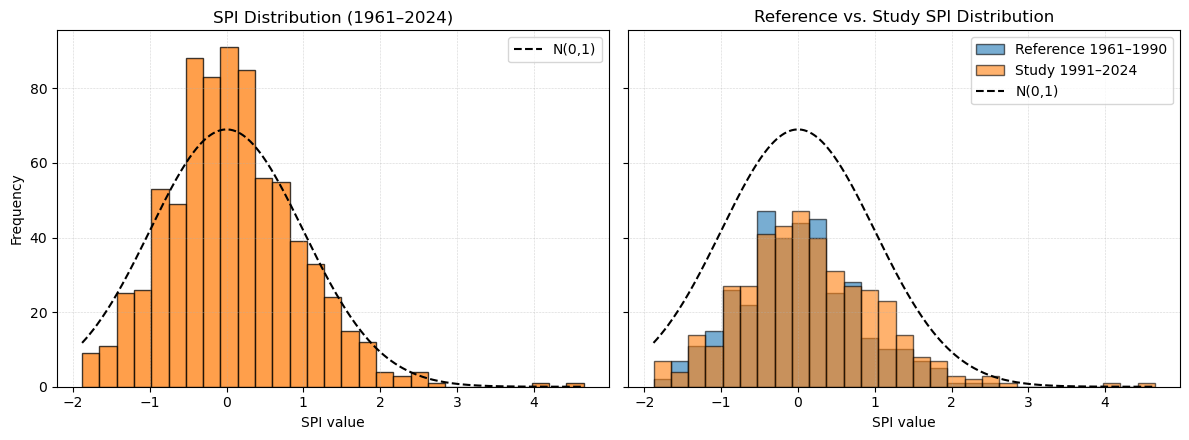

In [31]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# ── 0. Load your cleaned SPI from disk once ───────────────────────────────
da = xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/precipitation_index.nc")

# ── 1. Collapse over ‘step’ to get a 1-D monthly series ────────────────────
monthly_spi = da.mean(dim="step")
spi = monthly_spi.sel(time=slice("1961-01-01", None)).compute()
ser = spi.to_series().dropna()

# ── 2. Split reference vs study periods ───────────────────────────────────
ser_ref   = ser.loc["1961-01-01":"1990-12-31"]
ser_study = ser.loc["1991-01-01":"2024-12-31"]

# ── 3. Define common bin edges for fair comparison ────────────────────────
bins = np.linspace(ser.min(), ser.max(), 30)

# ── 4. Build the two‐panel figure ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

# Left: overall SPI distribution 1961–2024
axes[0].hist(
    ser.values, bins=bins,
    color="tab:orange", alpha=0.75, edgecolor="black"
)
x = np.linspace(bins[0], bins[-1], 400)
axes[0].plot(
    x,
    len(ser) * (bins[1] - bins[0]) * stats.norm.pdf(x),
    color="black", ls="--", lw=1.5, label="N(0,1)"
)
axes[0].set_title("SPI Distribution (1961–2024)")
axes[0].set_xlabel("SPI value")
axes[0].set_ylabel("Frequency")
axes[0].grid(True, ls=":", lw=0.4)
axes[0].legend()

# Right: reference vs. study overlay
axes[1].hist(
    ser_ref.values, bins=bins,
    color="tab:blue", alpha=0.6, edgecolor="black",
    label="Reference 1961–1990"
)
axes[1].hist(
    ser_study.values, bins=bins,
    color="tab:orange", alpha=0.6, edgecolor="black",
    label="Study 1991–2024"
)
axes[1].plot(
    x,
    len(ser) * (bins[1] - bins[0]) * stats.norm.pdf(x),
    color="black", ls="--", lw=1.5, label="N(0,1)"
)
axes[1].set_title("Reference vs. Study SPI Distribution")
axes[1].set_xlabel("SPI value")
axes[1].grid(True, ls=":", lw=0.4)
axes[1].legend()

plt.tight_layout()

# ── 5. Save the combined figure ───────────────────────────────────────────
fig.savefig("spi_histograms_side_by_side.png", dpi=300, bbox_inches="tight")
print("Plot saved as spi_histograms_side_by_side.png")

plt.show()





Plot saved as spi_frequency_3bars.png


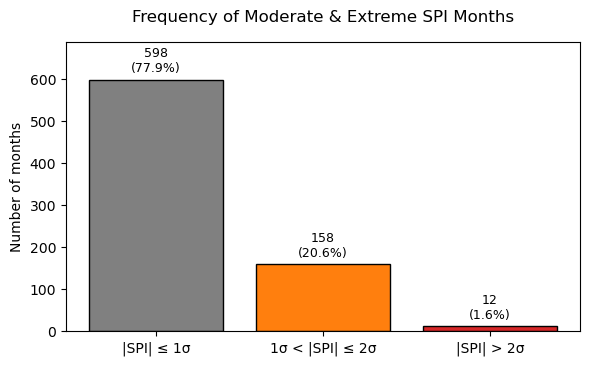

In [33]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Load cleaned SPI and collapse 'step' → 1-D monthly SPI ───────────
da = xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/precipitation_index.nc")
da_monthly = (
    da
    .mean(dim="step")                          # average over the 'step' dimension
    .sel(time=slice("1961-01-01", None))       # keep only from Jan 1961 onward
    .compute()                                 # in case it's dask-backed
)

# ── 2. Convert to pandas Series for counting ─────────────────────────────
ser   = da_monthly.to_series().dropna()        # one value per month
n_tot = len(ser)                               # total months

# ── 3. Compute tail counts ───────────────────────────────────────────────
n_above1 = (ser >  1).sum()   # SPI > +1σ
n_below1 = (ser < -1).sum()   # SPI < -1σ
n_above2 = (ser >  2).sum()   # SPI > +2σ
n_below2 = (ser < -2).sum()   # SPI < -2σ

# ── 4. Build the three bar counts ────────────────────────────────────────
count_le1   = n_tot - (n_above1 + n_below1)                  # |SPI| ≤ 1σ
count_1_2   = (n_above1 + n_below1) - (n_above2 + n_below2)  # 1σ < |SPI| ≤ 2σ
count_gt2   = n_above2 + n_below2                            # |SPI| > 2σ

counts  = [count_le1, count_1_2, count_gt2]
labels  = ["|SPI| ≤ 1σ", "1σ < |SPI| ≤ 2σ", "|SPI| > 2σ"]
percents = [c / n_tot * 100 for c in counts]

# ── 5. Plot bar chart with annotations ─────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    labels, counts,
    color=["grey", "tab:orange", "tab:red"],
    edgecolor="black"
)

ax.set_ylabel("Number of months")
ax.set_title("Frequency of Moderate & Extreme SPI Months", pad=15)

# Reserve vertical space above bars
max_count = max(counts)
ax.set_ylim(0, max_count * 1.15)

# Annotate each bar with count and percentage
for bar, pct in zip(bars, percents):
    x = bar.get_x() + bar.get_width()/2
    y = bar.get_height()
    ax.text(
        x, y + max_count * 0.02,
        f"{int(y):,}\n({pct:.1f}%)",
        ha="center", va="bottom",
        fontsize=9
    )

plt.tight_layout(rect=[0, 0, 1, 0.94])

# ── 6. Save for Docs ─────────────────────────────────────────────────────
fig.savefig("spi_frequency_3bars.png", dpi=300, bbox_inches="tight")
print("Plot saved as spi_frequency_3bars.png")

plt.show()



Plot saved as spi_timeseries_plot.png


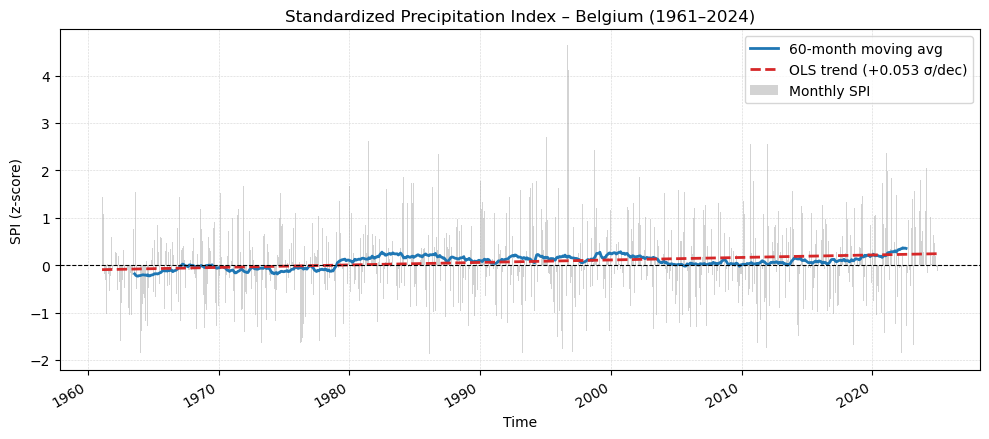

In [34]:
import xarray as xr
import matplotlib.dates as mdates
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

# ── 0. Load cleaned SPI from disk ──────────────────────────────────────────
da = xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/precipitation_index.nc")

# ── 1. Build the true 1-D monthly SPI series from `da` ────────────────────
monthly_spi = da.mean(dim="step")                            # collapse over “step”
spi_series  = (
    monthly_spi
    .sel(time=slice("1961-01-01", None))
    .compute()                                               # if dask-backed
    .to_series()
    .dropna()
)

# ── 2. Rolling mean & OLS trend on the monthly series ────────────────────
rolling_60   = spi_series.rolling(60, center=True).mean()
years        = spi_series.index.year + (spi_series.index.dayofyear - 1) / 365.25
slope, intercept, r, p, _ = stats.linregress(years, spi_series.values)
trend_series = pd.Series(intercept + slope * years, index=spi_series.index)

# ── 3. Plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))

# a) Bars for each month
ax.bar(
    spi_series.index,
    spi_series.values,
    width=25,
    color="lightgrey",
    label="Monthly SPI"
)

# b) 60-month centered rolling mean
ax.plot(
    rolling_60.index,
    rolling_60.values,
    color="tab:blue",
    lw=2,
    label="60-month moving avg"
)

# c) OLS trend line
ax.plot(
    trend_series.index,
    trend_series.values,
    color="tab:red",
    ls="--",
    lw=2,
    label=f"OLS trend ({slope*10:+.3f} σ/dec)"
)

ax.axhline(0, color="black", lw=0.8, ls="--")

ax.set_title("Standardized Precipitation Index – Belgium (1961–2024)")
ax.set_xlabel("Time")
ax.set_ylabel("SPI (z-score)")
ax.grid(True, ls=":", lw=0.4)
ax.legend()

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

plt.tight_layout()

# ── 4. Save figure ───────────────────────────────────────────────────────
fig.savefig("spi_timeseries_plot.png", dpi=300, bbox_inches="tight")
print("Plot saved as spi_timeseries_plot.png")

plt.show()


In [35]:
import time
import warnings
from dask.distributed import Client
from dask.diagnostics import ProgressBar

from aci.components.temperature_bis import TemperatureComponent

# ── Timer start ─────────────────────────────────────────────────────────
t0 = time.perf_counter()

# ── Suppress local warnings ───────────────────────────────────────────────
warnings.filterwarnings("ignore", category=RuntimeWarning, message="All-NaN slice encountered")
warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in divide")
warnings.filterwarnings("ignore", category=UserWarning, message="Sending large graph of size*")

# ── Setup Dask distributed client ───────────────────────────────────────
client = Client(n_workers=6, threads_per_worker=2, memory_limit='6GB')
print(client)

# ── Broadcast warning filters to all workers ─────────────────────────────
client.run(lambda: __import__('warnings').filterwarnings(
    'ignore', category=RuntimeWarning, message='All-NaN slice encountered'))
client.run(lambda: __import__('warnings').filterwarnings(
    'ignore', category=RuntimeWarning, message='invalid value encountered in divide'))
client.run(lambda: __import__('warnings').filterwarnings(
    'ignore', category=UserWarning, message='Sending large graph of size*'))

# ── Input paths & reference period ───────────────────────────────────────
temperature_path = "/Users/coralieroland/ACI-Python/data/required_data/temperature"
mask_path = "/Users/coralieroland/ACI-Python/data/required_data/mask_BEL.nc"
reference_period = ("1961-01-01", "1990-12-31")

# ── Instantiate t90 component ────────────────────────────────────────────
temperature90 = TemperatureComponent(
    temperature_data_path=temperature_path,
    mask_path=mask_path,
    percentile=90,
    extremum="max",
    above_thresholds=True
)

# ── Chunk dataset for parallelism ────────────────────────────────────────
temperature90.array = temperature90.array.chunk({"time": 60})

# ── Compute t90_index ───────────────────────────────────────────────────
print("⏳ Computing t90_index (this may take some time)...")
with ProgressBar():
    t90_index = temperature90.calculate_component(
        reference_period,
        area=True
    ).compute()

# ── Clean result ─────────────────────────────────────────────────────────
t90_index = t90_index.sel(time=slice("1961-01-01", None))

# ── Output & statistics ─────────────────────────────────────────────────
print("✅ t90 Index calculated successfully!\n")
print(t90_index)

print("\n📊 Summary Statistics:")
print(f"Min:   {t90_index.min().item():.3f}")
print(f"Max:   {t90_index.max().item():.3f}")
print(f"Mean:  {t90_index.mean().item():.3f}")
print(f"Std:   {t90_index.std().item():.3f}")
print(f"NaNs:  {t90_index.isnull().sum().item()}")

# ── Save cleaned St90I ─────────────────────────────────────────────────────
output_path = "/Users/coralieroland/ACI-Python/data/composites/t90_index.nc"
print(f"Saving t90 Index to {output_path}…")
t90_index.to_netcdf(output_path)

# ── Timer end ───────────────────────────────────────────────────────────
t1 = time.perf_counter()
print(f"\n⏱️ Total run time: {t1 - t0:.2f} seconds")

# ── Close client ────────────────────────────────────────────────────────
client.close()


/Users/coralieroland/miniconda3/envs/aci-env/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 52026 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:52027' processes=6 threads=12, memory=33.53 GiB>
⏳ Computing t90_index (this may take some time)...


/Users/coralieroland/miniconda3/envs/aci-env/lib/python3.10/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 52 times more chunks
  return self.array[key]
/Users/coralieroland/miniconda3/envs/aci-env/lib/python3.10/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 52 times more chunks
  return self.array[key]
/Users/coralieroland/miniconda3/envs/aci-env/lib/python3.10/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 65 times more chunks
  return self.array[key]
/Users/coralieroland/miniconda3/envs/aci-env/lib/python3.10/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 65 times more chunks
  return self.array[key]


✅ t90 Index calculated successfully!

<xarray.DataArray 't2m' (time: 768)> Size: 6kB
array([-5.25215533e-01,  1.74973393e+00,  1.22061304e+00,  2.71291990e+00,
       -6.11363995e-01, -3.80083008e-02, -8.44836965e-01, -6.05726891e-01,
        2.37652217e+00,  8.19984944e-01, -1.17615669e+00,  9.18214425e-01,
        5.86049548e-01, -5.53806227e-01, -1.44596639e+00, -4.64758086e-01,
       -1.34997354e+00, -4.42078419e-01, -5.58598449e-01, -2.53192715e-01,
       -5.49170007e-01, -1.30516965e-01, -7.82616490e-01, -8.65125913e-01,
       -1.46727586e+00, -1.48108267e+00,  6.11933212e-02,  5.53232343e-01,
       -1.00129274e+00,  9.21454885e-04,  7.52809240e-02, -1.44036534e+00,
       -1.48450908e-01, -2.19255275e-01,  1.93014589e+00, -1.12664880e+00,
       -1.32480194e+00,  7.28333044e-02, -6.69282967e-01,  4.38633452e-01,
        1.56705837e+00,  9.35291567e-01,  6.49817450e-01, -3.41797129e-02,
        8.48277261e-01, -1.48344068e+00,  6.78317266e-01,  6.92339775e-03,
       -2.67285

Plot saved as t90_bars_and_moving_avg_fullwindow.png


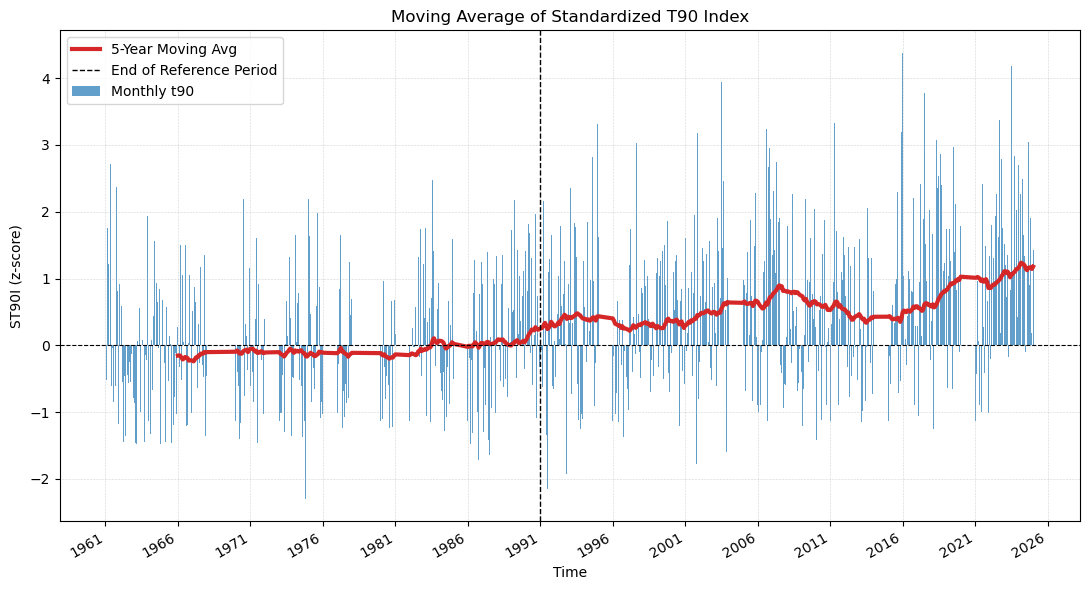

In [36]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# ── 1. Load cleaned t90 Index from disk ───────────────────────────────────
da = xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/t90_index.nc")

# ── 2. (If present) collapse over 'step' → 1-D monthly t90 series ─────────
#    (for t90_index there is no 'step', so this is a no-op)
if "step" in da.dims:
    da = da.mean(dim="step")

# ── 3. Clean to study period and drop NaNs ────────────────────────────────
t90_series = (
    da
    .sel(time=slice("1961-01-01", None))
    .to_series()
    .dropna()
)

# ── 4. Compute right-aligned 60-month rolling mean (full-window only) ─────
rolling_60 = (
    t90_series
    .rolling(window=60, center=False, min_periods=60)
    .mean()
    .dropna()
)

# ── 5. Plot bars + moving average ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

# a) Monthly t90 bars
ax.bar(
    t90_series.index,
    t90_series.values,
    width=25,
    color="tab:blue",
    alpha=0.7,
    label="Monthly t90"
)

# b) 5-year moving average line
ax.plot(
    rolling_60.index,
    rolling_60.values,
    color="tab:red",
    linewidth=3,
    label="5-Year Moving Avg"
)

# ── Add vertical line at end of reference period ──────────────────────────
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(ref_end, color="black", linestyle="--", linewidth=1, label="End of Reference Period")

# ── Cosmetics ─────────────────────────────────────────────────────────────
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Moving Average of Standardized T90 Index")
ax.set_xlabel("Time")
ax.set_ylabel("ST90I (z-score)")
ax.grid(True, linestyle=":", linewidth=0.4)
ax.legend()

# ── Custom 5-year x-axis ticks ────────────────────────────────────────────
years = list(range(1961, pd.Timestamp.today().year + 2, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.autofmt_xdate()
plt.tight_layout()

# ── Save figure ───────────────────────────────────────────────────────────
fig.savefig("t90_bars_and_moving_avg_fullwindow.png", dpi=300, bbox_inches="tight")
print("Plot saved as t90_bars_and_moving_avg_fullwindow.png")

plt.show()


In [37]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy import stats

# ── 1. Load cleaned t90 Index ───────────────────────────────────────────────
da = (
    xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/t90_index.nc")
      .sel(time=slice("1961-01-01", None))
)

# ── 2. Collapse over 'step' if present (for t90 it's already 1-D) ─────────
if "step" in da.dims:
    da = da.mean(dim="step")

# Force load into memory
da = da.compute()

# ── 3. Convert to pandas Series and drop NaNs ──────────────────────────────
ser   = da.to_series().dropna()
n_tot = ser.size

# ── 4. Descriptive statistics ─────────────────────────────────────────────
desc  = ser.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew  = ser.skew()
kurt  = ser.kurtosis()

# ── 5. Event counts ────────────────────────────────────────────────────────
#  moderate: 1σ < |t90| ≤ 2σ
n_mod_pos = ((ser > 1) & (ser <= 2)).sum()
n_mod_neg = ((ser < -1) & (ser >= -2)).sum()
n_mod     = n_mod_pos + n_mod_neg

#  extreme: |t90| > 2σ
n_extreme = ((ser > 2) | (ser < -2)).sum()

# ── 6. Linear trend (OLS) ─────────────────────────────────────────────────
years      = ser.index.year + (ser.index.dayofyear - 1) / 365.25
slope, intercept, r, p, _ = stats.linregress(years, ser.values)

# ── 7. Print results ─────────────────────────────────────────────────────
print("\n📊 Descriptive statistics for t90_index")
print(desc.to_string(float_format="%.3f"))
print(f"skewness : {skew:6.3f}")
print(f"kurtosis : {kurt:6.3f}")

print("\n⚠️  Moderate‐event frequency (1σ < |t90| ≤ 2σ)")
print(f"{n_mod:3d} / {n_tot}   ({n_mod/n_tot:5.1%})")

print("\n🚨  Extreme‐event frequency (|t90| > 2σ)")
print(f"{n_extreme:3d} / {n_tot}   ({n_extreme/n_tot:5.1%})")

print("\n📈  Linear trend (OLS on standardized t90)")
print(f"slope (per year)   : {slope: .4f}")
print(f"slope (per decade) : {slope*10: .4f}")
print(f"R²                 : {r**2: .3f}")
print(f"p-value            : {p: .3e}")



📊 Descriptive statistics for t90_index
count   634.000
mean      0.376
std       1.145
min      -2.294
5%       -1.246
25%      -0.515
50%       0.290
75%       1.153
95%       2.355
max       4.382
skewness :  0.445
kurtosis : -0.114

⚠️  Moderate‐event frequency (1σ < |t90| ≤ 2σ)
213 / 634   (33.6%)

🚨  Extreme‐event frequency (|t90| > 2σ)
 52 / 634   ( 8.2%)

📈  Linear trend (OLS on standardized t90)
slope (per year)   :  0.0210
slope (per decade) :  0.2098
R²                 :  0.116
p-value            :  1.157e-18


In [38]:
import time
import warnings
from dask.distributed import Client
from dask.diagnostics import ProgressBar

from aci.components.temperature_bis import TemperatureComponent

# ── Timer start ─────────────────────────────────────────────────────────
t0 = time.perf_counter()

# ── Suppress local warnings ───────────────────────────────────────────────
warnings.filterwarnings("ignore", category=RuntimeWarning, message="All-NaN slice encountered")
warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in divide")
warnings.filterwarnings("ignore", category=UserWarning,   message="Sending large graph of size*")

# ── Setup Dask distributed client ───────────────────────────────────────
client = Client(n_workers=6, threads_per_worker=2, memory_limit='6GB')
print(client)

# ── Broadcast warning filters to all workers ─────────────────────────────
client.run(lambda: __import__('warnings').filterwarnings(
    'ignore', category=RuntimeWarning, message='All-NaN slice encountered'))
client.run(lambda: __import__('warnings').filterwarnings(
    'ignore', category=RuntimeWarning, message='invalid value encountered in divide'))
client.run(lambda: __import__('warnings').filterwarnings(
    'ignore', category=UserWarning,   message='Sending large graph of size*'))

# ── Input paths & reference period ───────────────────────────────────────
temperature_path = "/Users/coralieroland/ACI-Python/data/required_data/temperature"
mask_path        = "/Users/coralieroland/ACI-Python/data/required_data/mask_BEL.nc"
reference_period = ("1961-01-01", "1990-12-31")

# ── Instantiate t10 component ────────────────────────────────────────────
temperature10 = TemperatureComponent(
    temperature_data_path=temperature_path,
    mask_path=mask_path,
    percentile=10,
    extremum="min",
    above_thresholds=False
)

# ── Chunk dataset for parallelism ────────────────────────────────────────
temperature10.array = temperature10.array.chunk({"time": 60})

# ── Compute t10_index ───────────────────────────────────────────────────
print("⏳ Computing t10_index (this may take some time)...")
with ProgressBar():
    t10_index = temperature10.calculate_component(
        reference_period,
        area=True
    ).compute()

# ── Clean result ─────────────────────────────────────────────────────────
t10_index = t10_index.sel(time=slice("1961-01-01", None))

# ── Output & statistics ─────────────────────────────────────────────────
print("✅ t10 Index calculated successfully!\n")
print(t10_index)

print("\n📊 Summary Statistics:")
print(f"Min:   {t10_index.min().item():.3f}")
print(f"Max:   {t10_index.max().item():.3f}")
print(f"Mean:  {t10_index.mean().item():.3f}")
print(f"Std:   {t10_index.std().item():.3f}")
print(f"NaNs:  {t10_index.isnull().sum().item()}")

# ── Save cleaned St10I ─────────────────────────────────────────────────────
output_path = "/Users/coralieroland/ACI-Python/data/composites/t10_index.nc"
print(f"Saving t10 Index to {output_path}…")
t10_index.to_netcdf(output_path)

# ── Timer end ───────────────────────────────────────────────────────────
t1 = time.perf_counter()
print(f"\n⏱️ Total run time: {t1 - t0:.2f} seconds")

# ── Close client ────────────────────────────────────────────────────────
client.close()


/Users/coralieroland/miniconda3/envs/aci-env/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 52873 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:52874' processes=6 threads=12, memory=33.53 GiB>
⏳ Computing t10_index (this may take some time)...


/Users/coralieroland/miniconda3/envs/aci-env/lib/python3.10/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 52 times more chunks
  return self.array[key]
/Users/coralieroland/miniconda3/envs/aci-env/lib/python3.10/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 52 times more chunks
  return self.array[key]
/Users/coralieroland/miniconda3/envs/aci-env/lib/python3.10/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 65 times more chunks
  return self.array[key]
/Users/coralieroland/miniconda3/envs/aci-env/lib/python3.10/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 65 times more chunks
  return self.array[key]


✅ t10 Index calculated successfully!

<xarray.DataArray 't2m' (time: 768)> Size: 6kB
array([-0.21995579, -1.00223073, -0.82515559, -1.67570616,  0.49154881,
       -0.13273748,  1.05140025,  0.77923269, -1.26600212, -1.11820225,
       -0.29988365,  0.88837213, -0.06344081,  0.13473526,  2.37101618,
       -0.45593876,  2.02729444,  2.30753634,  1.65479828,  1.04258042,
        1.37266016,  0.02267705,  0.54215824,  1.75540871,  3.09782845,
        2.34704753,  0.20095909, -0.76333013,  1.48196714, -1.06094331,
        0.25855981,  1.18743692, -0.50045821,  0.79293902, -1.4270016 ,
        1.86117219,  0.37526543, -0.28207019,  0.83470808, -1.00587448,
       -1.31268697,  0.71327975, -0.35065813,  0.05033397, -0.1714542 ,
        1.29743272, -0.0274475 ,  0.55016221, -0.49591721,  0.82140442,
        0.55940601, -0.64610698,  0.11968579, -0.23562265,  1.06162189,
        0.80045852,  0.95159712,  0.47682538,  1.82885782, -0.89551606,
        1.04687121, -0.85607172, -0.48801542, -1.02

Plot saved as t10_bars_and_moving_avg_fullwindow.png


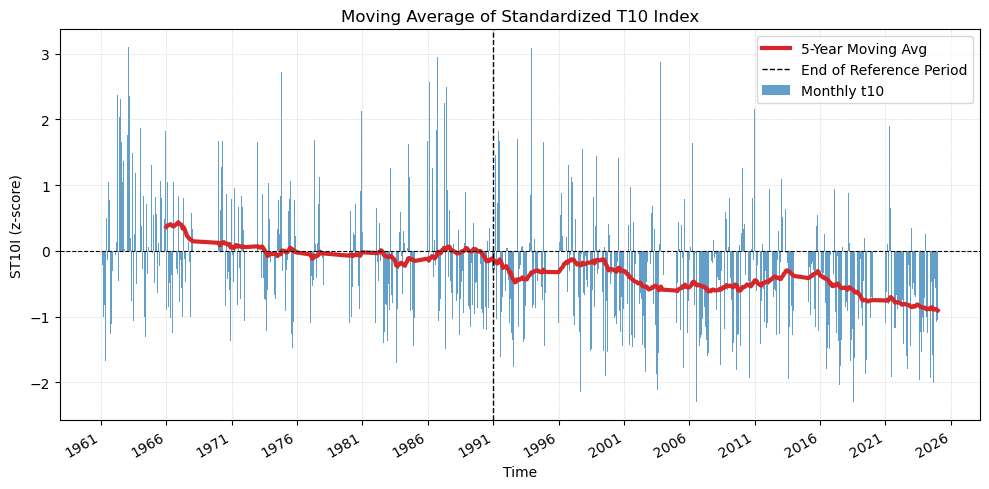

In [39]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# ── 1. Load cleaned t10 Index from disk ───────────────────────────────────
da = xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/t10_index.nc")

# ── 2. (If present) collapse over 'step' → 1-D monthly t10 series ────────
#    (for t10_index there is no 'step', so this is a no-op)
if "step" in da.dims:
    da = da.mean(dim="step")

# ── 3. Clean to study period and drop NaNs ───────────────────────────────
t10_series = (
    da
    .sel(time=slice("1961-01-01", None))
    .to_series()
    .dropna()
)

# ── 4. Compute right-aligned 60-month rolling mean (full-window only) ────
rolling_60 = (
    t10_series
    .rolling(window=60, center=False, min_periods=60)
    .mean()
    .dropna()
)

# ── 5. Plot bars + moving average ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# a) Monthly t10 bars in orange
ax.bar(
    t10_series.index,
    t10_series.values,
    width=25,
    color="tab:blue",
    alpha=0.7,
    label="Monthly t10"
)

# b) 5-year moving average line in red
ax.plot(
    rolling_60.index,
    rolling_60.values,
    color="tab:red",
    linewidth=3,
    label="5-Year Moving Avg"
)

# ── Add vertical line at end of reference period ──────────────────────────
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(ref_end, color="black", linestyle="--", linewidth=1, label="End of Reference Period")

# ── Cosmetics ─────────────────────────────────────────────────────────────
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Moving Average of Standardized T10 Index")
ax.set_xlabel("Time")
ax.set_ylabel("ST10I (z-score)")
ax.grid(True, linestyle=":", linewidth=0.4)
ax.legend()

# ── Custom 5-year x-axis ticks ────────────────────────────────────────────
years = list(range(1961, datetime.datetime.today().year + 2, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.autofmt_xdate()
plt.tight_layout()

# ── Save figure ───────────────────────────────────────────────────────────
fig.savefig("t10_bars_and_moving_avg_fullwindow.png", dpi=300, bbox_inches="tight")
print("Plot saved as t10_bars_and_moving_avg_fullwindow.png")

plt.show()


In [40]:
import numpy as np
import pandas as pd
from scipy import stats

# ── Convert t10_index to a pandas Series and drop NaNs ────────────────
ser = t10_index.to_series().dropna()
n_tot = ser.size

# ── Handle MultiIndex: extract the time level if needed ────────────────
if isinstance(ser.index, pd.MultiIndex):
    time_index = ser.index.get_level_values("time")
else:
    time_index = ser.index

# ── 1. Descriptive statistics ──────────────────────────────────────────
desc = ser.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew = ser.skew()
kurt = ser.kurtosis()

# ── 2. Frequency of “extreme” t10 (|z| >1σ and |z| >2σ) ─────────────────
n_above1 = (ser >  1).sum();  n_below1 = (ser < -1).sum()
n_above2 = (ser >  2).sum();  n_below2 = (ser < -2).sum()

# ── 3. Linear trend (ordinary least squares) ───────────────────────────
years = time_index.year + (time_index.dayofyear - 1) / 365.25
slope, intercept, r, p, _ = stats.linregress(years, ser.values)

# ── 4. Print results ───────────────────────────────────────────────────
print("\n📊  Descriptive statistics for t10_index")
print(desc.to_string(float_format="%.3f"))
print(f"skewness  : {skew:6.3f}")
print(f"kurtosis  : {kurt:6.3f}")

print("\n⚠️  Extreme‐event frequency (|t10| > σ thresholds)")
print(f"|t10| > 1σ : {n_above1 + n_below1:3d} / {n_tot}  "
      f"({(n_above1 + n_below1)/n_tot:5.1%})")
print(f"|t10| > 2σ : {n_above2 + n_below2:3d} / {n_tot}  "
      f"({(n_above2 + n_below2)/n_tot:5.1%})")

print("\n📈  Linear trend (OLS on standardized t10)")
print(f"slope (per year)   : {slope: .4f}")
print(f"slope (per decade) : {slope*10: .4f}")
print(f"R²                 : {r**2: .3f}")
print(f"p-value            : {p: .3e}")



📊  Descriptive statistics for t10_index
count   634.000
mean     -0.303
std       0.968
min      -2.301
5%       -1.603
25%      -0.996
50%      -0.453
75%       0.231
95%       1.651
max       3.098
skewness  :  0.772
kurtosis  :  0.564

⚠️  Extreme‐event frequency (|t10| > σ thresholds)
|t10| > 1σ : 221 / 634  (34.9%)
|t10| > 2σ :  25 / 634  ( 3.9%)

📈  Linear trend (OLS on standardized t10)
slope (per year)   : -0.0175
slope (per decade) : -0.1748
R²                 :  0.113
p-value            :  3.684e-18


Plot saved as temperature_bars_and_moving_avg_fullwindow.png


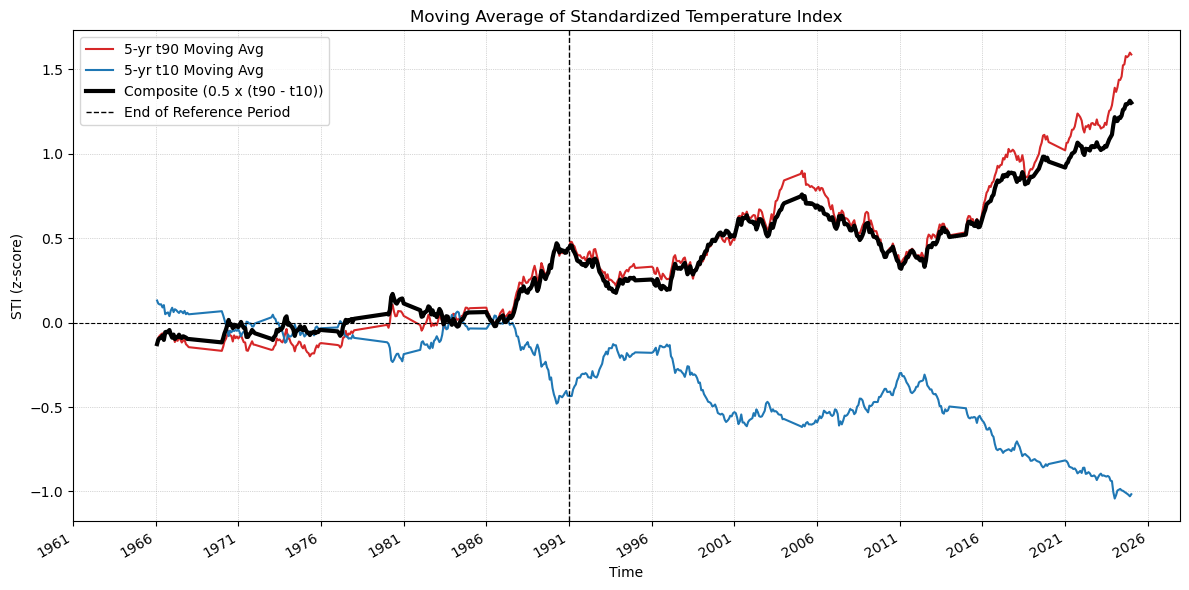

In [44]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# ── 1. Load your saved indices (1961 onward) ─────────────────────────────
t90 = (
    xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/t90_index.nc")
      .sel(time=slice("1961-01-01", None))
      .to_series()
      .dropna()
)
t10 = (
    xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/t10_index.nc")
      .sel(time=slice("1961-01-01", None))
      .to_series()
      .dropna()
)

# ── 2. Compute composite series ────────────────────────────────────────────
comp = (0.5 * (t90 - t10)).dropna()

# ── 3. Compute 60-month centered rolling means ─────────────────────────────
r90 = t90.rolling(window=60, center=True, min_periods=1).mean()
r10 = t10.rolling(window=60, center=True, min_periods=1).mean()
rc  = comp.rolling(window=60, center=True, min_periods=1).mean()

# ── 4. Restrict rolling-mean to 1966–2024 ────────────────────────────────
r90 = r90.loc["1966-01-01":"2024-12-31"]
r10 = r10.loc["1966-01-01":"2024-12-31"]
rc  = rc.loc["1966-01-01":"2024-12-31"]

# ── 5. Plot only the rolling means ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(r90.index, r90.values, color='tab:red',   linewidth=1.5, label='5-yr t90 Moving Avg')
ax.plot(r10.index, r10.values, color='tab:blue',  linewidth=1.5, label='5-yr t10 Moving Avg')
ax.plot(rc.index,  rc.values,  color='black',  linewidth=3, label='Composite (0.5 x (t90 - t10))')

# ── Reference-period end marker ───────────────────────────────────────────
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(ref_end, color='black', linestyle='--', linewidth=1, label='End of Reference Period')

# ── Zero line & grid ──────────────────────────────────────────────────────
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.grid(True, linestyle=":", linewidth=0.5)

# ── Labels & title ────────────────────────────────────────────────────────
ax.set_title("Moving Average of Standardized Temperature Index")
ax.set_xlabel("Time")
ax.set_ylabel("STI (z-score)")

# ── 5-year x-ticks from 1961 to 2026 ─────────────────────────────────────
years = list(range(1961, 2027, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

# ── Legend & layout ───────────────────────────────────────────────────────
ax.legend(loc='upper left')
plt.tight_layout()

# ── Save figure ───────────────────────────────────────────────────────────
fig.savefig("temperature_bars_and_moving_avg_fullwindow.png", dpi=300, bbox_inches="tight")
print("Plot saved as temperature_bars_and_moving_avg_fullwindow.png")

plt.show()

Plot saved as NEWtemperature_bars_and_moving_avg_fullwindow.png


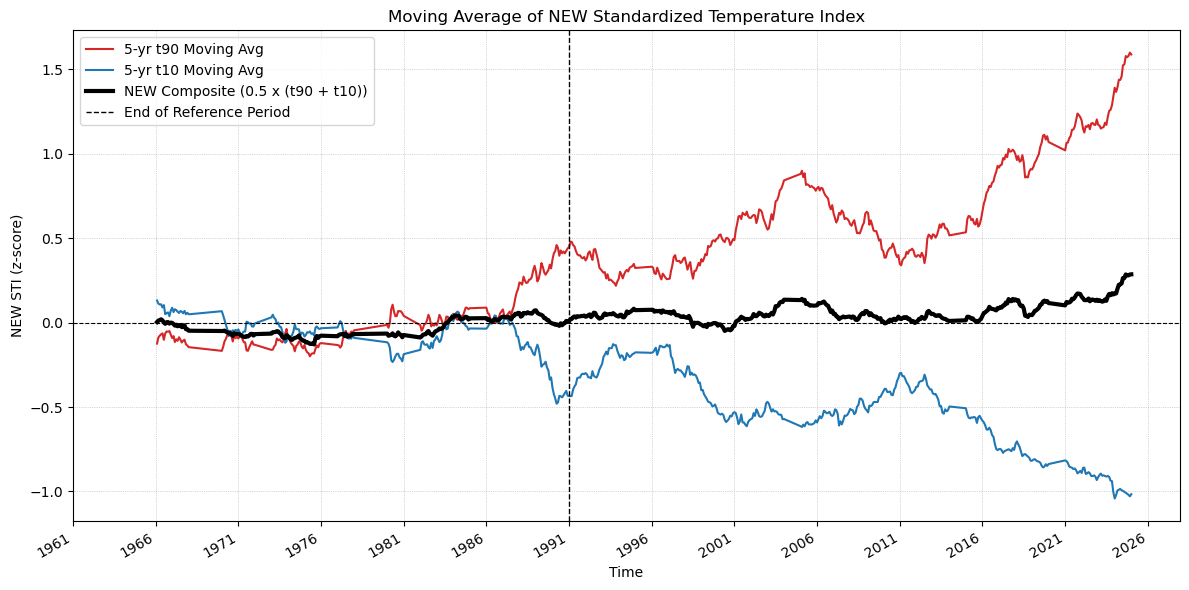

In [45]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# ── 1. Load your saved indices (1961 onward) ─────────────────────────────
t90 = (
    xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/t90_index.nc")
      .sel(time=slice("1961-01-01", None))
      .to_series()
      .dropna()
)
t10 = (
    xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/t10_index.nc")
      .sel(time=slice("1961-01-01", None))
      .to_series()
      .dropna()
)

# ── 2. Compute composite series ────────────────────────────────────────────
comp = (0.5 * (t90 + t10)).dropna()

# ── 3. Compute 60-month centered rolling means ─────────────────────────────
r90 = t90.rolling(window=60, center=True, min_periods=1).mean()
r10 = t10.rolling(window=60, center=True, min_periods=1).mean()
rc  = comp.rolling(window=60, center=True, min_periods=1).mean()

# ── 4. Restrict rolling-mean to 1966–2024 ────────────────────────────────
r90 = r90.loc["1966-01-01":"2024-12-31"]
r10 = r10.loc["1966-01-01":"2024-12-31"]
rc  = rc.loc["1966-01-01":"2024-12-31"]

# ── 5. Plot only the rolling means ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(r90.index, r90.values, color='tab:red',   linewidth=1.5, label='5-yr t90 Moving Avg')
ax.plot(r10.index, r10.values, color='tab:blue',  linewidth=1.5, label='5-yr t10 Moving Avg')
ax.plot(rc.index,  rc.values,  color='black',  linewidth=3, label='NEW Composite (0.5 x (t90 + t10))')

# ── Reference-period end marker ───────────────────────────────────────────
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(ref_end, color='black', linestyle='--', linewidth=1, label='End of Reference Period')

# ── Zero line & grid ──────────────────────────────────────────────────────
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.grid(True, linestyle=":", linewidth=0.5)

# ── Labels & title ────────────────────────────────────────────────────────
ax.set_title("Moving Average of NEW Standardized Temperature Index")
ax.set_xlabel("Time")
ax.set_ylabel("NEW STI (z-score)")

# ── 5-year x-ticks from 1961 to 2026 ─────────────────────────────────────
years = list(range(1961, 2027, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

# ── Legend & layout ───────────────────────────────────────────────────────
ax.legend(loc='upper left')
plt.tight_layout()

# ── Save figure ───────────────────────────────────────────────────────────
fig.savefig("NEWtemperature_bars_and_moving_avg_fullwindow.png", dpi=300, bbox_inches="tight")
print("Plot saved as NEWtemperature_bars_and_moving_avg_fullwindow.png")

plt.show()

In [46]:
import time
import warnings
from dask.distributed import Client
from dask.diagnostics import ProgressBar

from aci.components.wind_bis import WindComponent

# ── Timer start ─────────────────────────────────────────────────────────
t0 = time.perf_counter()

# ── Suppress local warnings ─────────────────────────────────────────────
warnings.filterwarnings("ignore", category=RuntimeWarning, message="All-NaN slice encountered")
warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in divide")
warnings.filterwarnings("ignore", category=UserWarning, message="Sending large graph of size*")

# ── Setup Dask distributed client ───────────────────────────────────────
client = Client(n_workers=6, threads_per_worker=2, memory_limit='6GB')
print(client)

# ── Broadcast warning filters to all workers ─────────────────────────────
client.run(lambda: __import__('warnings').filterwarnings(
    'ignore', category=RuntimeWarning, message='All-NaN slice encountered'))
client.run(lambda: __import__('warnings').filterwarnings(
    'ignore', category=RuntimeWarning, message='invalid value encountered in divide'))
client.run(lambda: __import__('warnings').filterwarnings(
    'ignore', category=UserWarning, message='Sending large graph of size*'))

# ── Input paths & reference period ───────────────────────────────────────
u10_path = "/Users/coralieroland/ACI-Python/data/required_data/wind_u10"
v10_path = "/Users/coralieroland/ACI-Python/data/required_data/wind_v10"
mask_path = "/Users/coralieroland/ACI-Python/data/required_data/mask_BEL.nc"
reference_period = ("1961-01-01", "1990-12-31")

# ── Instantiate the WindComponent ───────────────────────────────────────
wind = WindComponent(
    u10_path=u10_path,
    v10_path=v10_path,
    mask_path=mask_path
)

# ── Optional: chunk u10 and v10 datasets for better parallelism ─────────
wind.u10 = wind.u10.chunk({"time": 60})
wind.v10 = wind.v10.chunk({"time": 60})

# ── Compute wind index with progress bar ────────────────────────────────
print("⏳ Computing Wind Index (this may take some time)...")
with ProgressBar():
    wind_index = wind.calculate_component(
        reference_period=reference_period,
        area=True
    ).compute()

# ── Clean result: remove pre-1961 time values if needed ─────────────────
wind_index = wind_index.sel(time=slice("1961-01-01", None))

# ── Output & statistics ─────────────────────────────────────────────────
print("✅ Wind Index calculated successfully!\n")
print(wind_index)

print("\n📊 Summary Statistics:")
print(f"Min:   {wind_index.min().item():.3f}")
print(f"Max:   {wind_index.max().item():.3f}")
print(f"Mean:  {wind_index.mean().item():.3f}")
print(f"Std:   {wind_index.std().item():.3f}")
print(f"NaNs:  {wind_index.isnull().sum().item()}")

# ── Save cleaned SWI ─────────────────────────────────────────────────────
output_path = "/Users/coralieroland/ACI-Python/data/composites/wind_index.nc"
print(f"Saving Wind Index to {output_path}…")
wind_index.to_netcdf(output_path)

# ── Timer end ───────────────────────────────────────────────────────────
t1 = time.perf_counter()
print(f"\n⏱️ Total run time: {t1 - t0:.2f} seconds")

# ── Close Dask client ───────────────────────────────────────────────────
client.close()


/Users/coralieroland/miniconda3/envs/aci-env/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 53171 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:53172' processes=6 threads=12, memory=33.53 GiB>
⏳ Computing Wind Index (this may take some time)...


/Users/coralieroland/miniconda3/envs/aci-env/lib/python3.10/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 64 times more chunks
  return self.array[key]
/Users/coralieroland/miniconda3/envs/aci-env/lib/python3.10/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 64 times more chunks
  return self.array[key]
/Users/coralieroland/miniconda3/envs/aci-env/lib/python3.10/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 65 times more chunks
  return self.array[key]
/Users/coralieroland/miniconda3/envs/aci-env/lib/python3.10/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 65 times more chunks
  return self.array[key]


✅ Wind Index calculated successfully!

<xarray.DataArray 'wind' (time: 768)> Size: 6kB
array([ 3.04464600e-02,  8.43988336e-02, -4.31510946e-01, -9.27214534e-01,
        6.22025221e-01, -7.65234919e-01,  7.87421214e-01,  1.16388508e+00,
       -6.36826533e-01,  4.58015494e-01, -5.46277521e-01,  4.85759076e-01,
        1.00058925e+00,  1.26603061e+00, -1.03616683e+00,  1.58301984e+00,
        1.32586279e+00, -5.87196128e-01, -1.40523458e-01,  2.08020692e+00,
       -3.80692463e-01, -1.00770265e+00, -1.18815624e+00, -4.17758958e-01,
       -9.12228788e-01, -8.59640658e-01, -1.97865074e-01, -8.77512043e-01,
       -8.99584536e-01,  1.93429812e+00, -9.45945510e-01,  1.96895569e+00,
       -5.20712691e-01, -9.97670587e-01,  1.69814920e+00, -1.40039107e+00,
       -1.16014448e+00, -8.59640658e-01, -8.96666964e-01,  1.48419495e-01,
       -1.04028740e+00, -4.35978220e-01, -2.27287257e-01,  4.33493346e-01,
       -3.18917666e-01, -2.86748292e-01, -5.72482119e-01,  3.55409003e-01,
        1.596

Plot saved as wind_index_bars_and_moving_avg_fullwindow.png


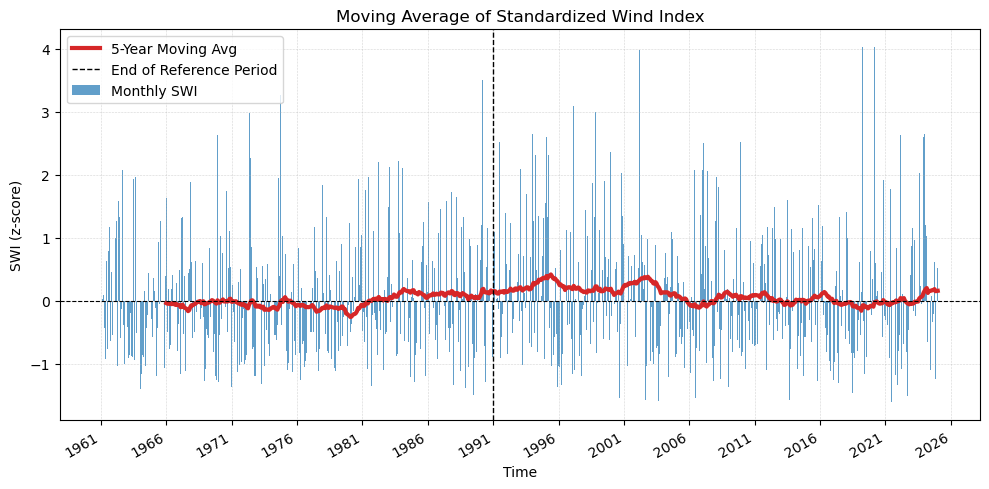

In [47]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# ── 1. Load cleaned wind Index from disk ─────────────────────────────────
da = xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/wind_index.nc")

# ── 2. (If present) collapse over 'step' → 1-D monthly series ───────────
if "step" in da.dims:
    da = da.mean(dim="step")

# ── 3. Clean to study period and drop NaNs ───────────────────────────────
wind_series = (
    da
    .sel(time=slice("1961-01-01", None))
    .to_series()
    .dropna()
)

# ── 4. Compute right-aligned 60-month rolling mean (full-window only) ────
rolling_60 = (
    wind_series
    .rolling(window=60, center=False, min_periods=60)
    .mean()
    .dropna()
)

# ── 5. Plot bars + moving average ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# a) Monthly wind index bars
ax.bar(
    wind_series.index,
    wind_series.values,
    width=25,
    color="tab:blue",
    alpha=0.7,
    label="Monthly SWI"
)

# b) 5-year moving average line
ax.plot(
    rolling_60.index,
    rolling_60.values,
    color="tab:red",
    linewidth=3,
    label="5-Year Moving Avg"
)

# ── Add vertical line at end of reference period ──────────────────────────
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(ref_end, color="black", linestyle="--", linewidth=1,
           label="End of Reference Period")

# ── Cosmetics ─────────────────────────────────────────────────────────────
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Moving Average of Standardized Wind Index")
ax.set_xlabel("Time")
ax.set_ylabel("SWI (z-score)")
ax.grid(True, linestyle=":", linewidth=0.4)
ax.legend()

# ── Custom 5-year x-axis ticks ────────────────────────────────────────────
years = list(range(1961, datetime.datetime.today().year + 2, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.autofmt_xdate()
plt.tight_layout()

# ── Save figure ───────────────────────────────────────────────────────────
fig.savefig("wind_index_bars_and_moving_avg_fullwindow.png", dpi=300, bbox_inches="tight")
print("Plot saved as wind_index_bars_and_moving_avg_fullwindow.png")

plt.show()


In [48]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy import stats

# ── 1. Load cleaned Wind Index ───────────────────────────────────────────
da = (
    xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/wind_index.nc")
      .sel(time=slice("1961-01-01", None))
)

# ── 2. Collapse over 'step' if present (usually not for saved index) ────
if "step" in da.dims:
    da = da.mean(dim="step")

# Force load into memory (resolve any dask laziness)
da = da.compute()

# ── 3. Convert to pandas Series and drop NaNs ────────────────────────────
ser   = da.to_series().dropna()
n_tot = ser.size

# ── 4. Descriptive statistics ───────────────────────────────────────────
desc  = ser.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew  = ser.skew()
kurt  = ser.kurtosis()

# ── 5. Event counts (z-score thresholds, since wind_index is standardized)
#  moderate: 1σ < |wind| ≤ 2σ
n_mod_pos = ((ser > 1) & (ser <= 2)).sum()
n_mod_neg = ((ser < -1) & (ser >= -2)).sum()
n_mod     = n_mod_pos + n_mod_neg

#  extreme: |wind| > 2σ
n_extreme = ((ser > 2) | (ser < -2)).sum()

# ── 6. Linear trend (OLS) ───────────────────────────────────────────────
years = ser.index.year + (ser.index.dayofyear - 1) / 365.25
slope, intercept, r, p, _ = stats.linregress(years, ser.values)

# ── 7. Print results ────────────────────────────────────────────────────
print("\n📊 Descriptive statistics for wind_index")
print(desc.to_string(float_format="%.3f"))
print(f"skewness : {skew:6.3f}")
print(f"kurtosis : {kurt:6.3f}")

print("\n⚠️  Moderate‐event frequency (1σ < |wind| ≤ 2σ)")
print(f"{n_mod:3d} / {n_tot}   ({n_mod/n_tot:5.1%})")

print("\n🚨  Extreme‐event frequency (|wind| > 2σ)")
print(f"{n_extreme:3d} / {n_tot}   ({n_extreme/n_tot:5.1%})")

print("\n📈  Linear trend (OLS on standardized wind_index)")
print(f"slope (per year)   : {slope: .4f}")
print(f"slope (per decade) : {slope*10: .4f}")
print(f"R²                 : {r**2: .3f}")
print(f"p-value            : {p: .3e}")



📊 Descriptive statistics for wind_index
count   768.000
mean      0.049
std       0.980
min      -1.612
5%       -1.199
25%      -0.685
50%      -0.119
75%       0.610
95%       1.955
max       4.027
skewness :  0.927
kurtosis :  0.883

⚠️  Moderate‐event frequency (1σ < |wind| ≤ 2σ)
182 / 768   (23.7%)

🚨  Extreme‐event frequency (|wind| > 2σ)
 35 / 768   ( 4.6%)

📈  Linear trend (OLS on standardized wind_index)
slope (per year)   :  0.0019
slope (per decade) :  0.0186
R²                 :  0.001
p-value            :  3.317e-01


In [49]:
import os
import xarray as xr
import time
import warnings
from aci.components.sealevel_bis import SeaLevelComponent
from dask.diagnostics import ProgressBar   # ← for lazy dask objects

# ── Start timer ──────────────────────────────────────────────────────────
t0 = time.perf_counter()

# ── Output path ─────────────────────────────────────────────────────────
output_path = "/Users/coralieroland/ACI-Python/data/composites/sealevel_index.nc"

# ── Instantiate component ────────────────────────────────────────────────
sea = SeaLevelComponent(
    country_abrev="BEL",
    # study_period is recorded but not used to trim by default
    study_period     = ("1961-01-01", "2024-12-31"),
    reference_period = ("1961-01-01", "1990-12-31")
)

# ── Build the index (lazy or eager) ───────────────────────────────────────
sealevel_index = sea.process()

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ── Compute if dask-backed; else it’s already a pandas DataFrame ─────────
if hasattr(sealevel_index, "compute"):
    with ProgressBar():
        sealevel_index_computed = sealevel_index.compute()
else:
    sealevel_index_computed = sealevel_index

# ── Now spans 1961-01-01 … 2024-12-31 ───────────────────────────────────
print("✅ Full Sea-Level Index calculated successfully!")
print(sealevel_index_computed)

# ── Summary statistics over the FULL period ──────────────────────────────
print("\nStats summary (1961–2024):")
min_val   = sealevel_index_computed.min().min()
max_val   = sealevel_index_computed.max().max()
mean_val  = sealevel_index_computed.stack().mean()
std_val   = sealevel_index_computed.stack().std()
nan_count = int(sealevel_index_computed.isnull().sum().sum())

print(f"min:        {min_val:.3f}")
print(f"max:        {max_val:.3f}")
print(f"mean:       {mean_val:.3f}")
print(f"std:        {std_val:.3f}")
print(f"count NaNs: {nan_count}")

# ── Save cleaned SSLI ─────────────────────────────────────────────────────
os.makedirs(os.path.dirname(output_path), exist_ok=True)
print(f"Saving Sea Level Index to {output_path}…")

# convert pandas DataFrame to xarray Dataset and write
sealevel_ds = sealevel_index_computed.to_xarray()
sealevel_ds.to_netcdf(output_path)

# ── End timer ─────────────────────────────────────────────────────────────
t1 = time.perf_counter()
print(f"\n⏱️  Total run time: {t1 - t0:.2f} seconds")



The directory rlr_monthly already exists. No action needed.
DataFrame loaded successfully.
✅ Full Sea-Level Index calculated successfully!
            Measurement_470  Measurement_489  Measurement_413
time                                                         
1961-01-01        -0.621127              NaN        -0.889430
1961-02-01         0.028970              NaN         0.270575
1961-03-01         0.288362              NaN         0.384505
1961-04-01        -2.692559              NaN         0.372448
1961-05-01         0.392225              NaN         1.214116
...                     ...              ...              ...
2024-08-01         3.651437         4.989565         3.910429
2024-09-01         3.288268         4.622177         3.694240
2024-10-01         1.906603         3.069146         2.264308
2024-11-01         1.546792         2.812283         1.949448
2024-12-01         1.278967              NaN         1.551383

[768 rows x 3 columns]

Stats summary (1961–2024):
min

Plot saved as sealevel_bars_and_moving_avg_fullwindow.png


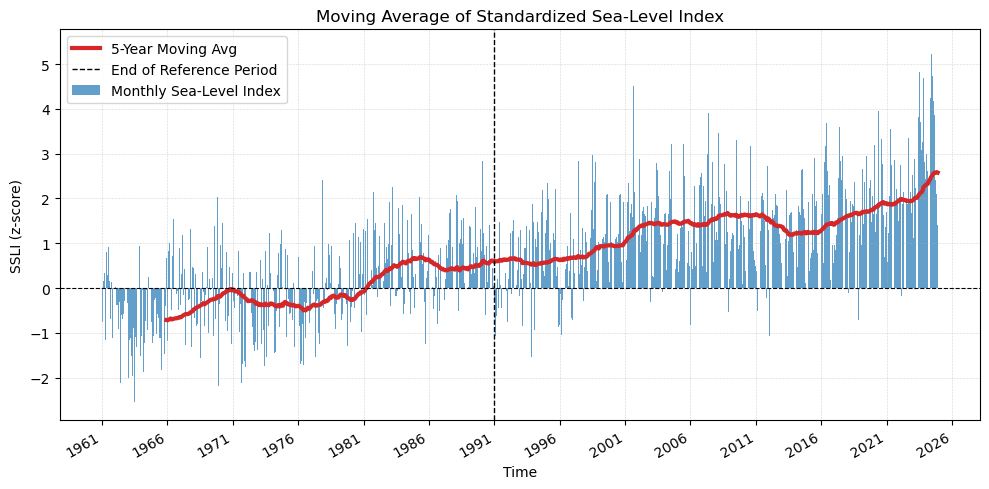

In [50]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# ── 1. Load cleaned Sea-Level Index from disk ────────────────────────────
ds = xr.open_dataset("/Users/coralieroland/ACI-Python/data/composites/sealevel_index.nc")

# ── 2. Combine all gauge variables into one monthly series ──────────────
#    .to_array() makes a DataArray with dims ("variable", "time")
da = ds.to_array(name="sealevel_index")
# average over the “variable” axis so you end up with one value per time step
da_mean = da.mean(dim="variable")

# ── 3. (If present) collapse over 'step' → 1-D monthly series ───────────
if "step" in da_mean.dims:
    da_mean = da_mean.mean(dim="step")

# ── 4. Clip to your full period (1961–2024) and drop NaNs ──────────────
series = (
    da_mean
    .sel(time=slice("1961-01-01", None))
    .to_series()
    .dropna()
)

# ── 5. Compute right-aligned 60-month rolling mean (min_periods=60) ─────
rolling_60 = (
    series
    .rolling(window=60, center=False, min_periods=60)
    .mean()
    .dropna()
)

# ── 6. Plot bars + moving average ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# a) Monthly sea-level bars
ax.bar(
    series.index,
    series.values,
    width=25,
    color="tab:blue",
    alpha=0.7,
    label="Monthly Sea-Level Index"
)

# b) 5-year moving average line
ax.plot(
    rolling_60.index,
    rolling_60.values,
    color="tab:red",
    linewidth=3,
    label="5-Year Moving Avg"
)

# ── 7. Mark end of reference period ─────────────────────────────────────
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(ref_end, color="black", linestyle="--", linewidth=1, label="End of Reference Period")

# ── 8. Cosmetics ───────────────────────────────────────────────────────
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Moving Average of Standardized Sea-Level Index")
ax.set_xlabel("Time")
ax.set_ylabel("SSLI (z-score)")
ax.grid(True, linestyle=":", linewidth=0.4)
ax.legend()

# ── 9. Custom 5-year x-axis ticks ──────────────────────────────────────
years = list(range(1961, datetime.datetime.today().year + 2, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.autofmt_xdate()
plt.tight_layout()

# ── 10. Save figure ────────────────────────────────────────────────────
fig.savefig("sealevel_bars_and_moving_avg_fullwindow.png", dpi=300, bbox_inches="tight")
print("Plot saved as sealevel_bars_and_moving_avg_fullwindow.png")

plt.show()


In [3]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy import stats

# ── 1) Load saved Sea‑Level Index ─────────────────────────────────────────
# Script 1 saved a Dataset with one variable per gauge (column).
ds = xr.open_dataset("ACI-Python/data/composites/sealevel_index.nc")

# Collapse gauges → single monthly series
# (to_array gives a DataArray with dims ("variable","time"))
da = ds.to_array(name="sealevel_index").mean(dim="variable")

# Keep full period (1961–… as available)
da = da.sel(time=slice("1961-01-01", None))

# If a 'step' dim exists (unlikely here), collapse it
if "step" in da.dims:
    da = da.mean(dim="step")

# Force load (resolve any dask laziness)
da = da.compute()

# ── 2) Convert to pandas Series and drop NaNs ─────────────────────────────
ser   = da.to_series().dropna()
n_tot = ser.size

# ── 3) Descriptive statistics ────────────────────────────────────────────
desc  = ser.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew  = ser.skew()
kurt  = ser.kurtosis()

# ── 4) Event counts (z-score thresholds; index is standardized) ──────────
# moderate: 1σ < |z| ≤ 2σ
n_mod_pos = ((ser > 1) & (ser <= 2)).sum()
n_mod_neg = ((ser < -1) & (ser >= -2)).sum()
n_mod     = n_mod_pos + n_mod_neg

# extreme: |z| > 2σ
n_extreme = ((ser > 2) | (ser < -2)).sum()

# ── 5) Linear trend (OLS) ────────────────────────────────────────────────
years = ser.index.year + (ser.index.dayofyear - 1) / 365.25
slope, intercept, r, p, _ = stats.linregress(years, ser.values)

# ── 6) Print results ─────────────────────────────────────────────────────
print("\n📊 Descriptive statistics for sealevel_index (country-mean series)")
print(desc.to_string(float_format="%.3f"))
print(f"skewness : {skew:6.3f}")
print(f"kurtosis : {kurt:6.3f}")

print("\n⚠️  Moderate-event frequency (1σ < |z| ≤ 2σ)")
print(f"{n_mod:3d} / {n_tot}   ({n_mod/n_tot:5.1%})")

print("\n🚨  Extreme-event frequency (|z| > 2σ)")
print(f"{n_extreme:3d} / {n_tot}   ({n_extreme/n_tot:5.1%})")

print("\n📈  Linear trend (OLS on standardized sealevel_index)")
print(f"slope (per year)   : {slope: .4f}")
print(f"slope (per decade) : {slope*10: .4f}")
print(f"R²                 : {r**2: .3f}")
print(f"p-value            : {p: .3e}")



📊 Descriptive statistics for sealevel_index (country-mean series)
count   768.000
mean      0.784
std       1.290
min      -2.544
5%       -1.228
25%      -0.166
50%       0.804
75%       1.648
95%       2.939
max       5.379
skewness :  0.272
kurtosis :  0.107

⚠️  Moderate-event frequency (1σ < |z| ≤ 2σ)
266 / 768   (34.6%)

🚨  Extreme-event frequency (|z| > 2σ)
130 / 768   (16.9%)

📈  Linear trend (OLS on standardized sealevel_index)
slope (per year)   :  0.0480
slope (per decade) :  0.4797
R²                 :  0.473
p-value            :  1.466e-108


In [52]:
import time
import warnings
from dask.diagnostics import ProgressBar
from aci.components.drought_bis import DroughtComponent

# ── Start timer ───────────────────────────────────────────────────────────
t0 = time.perf_counter()

# ── Instantiate component ─────────────────────────────────────────────────
drought = DroughtComponent(
    precipitation_data_path="/Users/coralieroland/ACI-Python/data/required_data/precipitation",
    mask_path="/Users/coralieroland/ACI-Python/data/required_data/mask_BEL.nc"
)

# ── Calculate standardized drought index (lazy / dask) ────────────────────
drought_index = drought.calculate_component(
    reference_period=("1961-01-01", "1990-12-31"),
    area=True
)

# ── Suppress harmless warnings ────────────────────────────────────────────
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ── Compute with progress bar ─────────────────────────────────────────────
with ProgressBar():
    drought_index_computed = drought_index.compute()

# ── Clean time range (drop pre-1961 if exists) ────────────────────────────
drought_index_cleaned = drought_index_computed.sel(time=slice("1961-01-01", None))

# ── Print stats ───────────────────────────────────────────────────────────
print("✅ Drought Index calculated and cleaned successfully!")
print(drought_index_cleaned)
print("📊 Stats summary:")
print(f"min:        {drought_index_cleaned.min().item():.3f}")
print(f"max:        {drought_index_cleaned.max().item():.3f}")
print(f"mean:       {drought_index_cleaned.mean().item():.3f}")
print(f"std:        {drought_index_cleaned.std().item():.3f}")
print(f"count NaNs: {float(drought_index_cleaned.isnull().sum().values)}")

# ── Save cleaned SDI ─────────────────────────────────────────────────────
output_path = "/Users/coralieroland/ACI-Python/data/composites/drought_index.nc"
print(f"Saving Drought Index to {output_path}…")
drought_index_cleaned.to_netcdf(output_path)

# ── Timer ─────────────────────────────────────────────────────────────────
t1 = time.perf_counter()
print(f"\n⏱️  Total run time: {t1 - t0:.2f} seconds")


/Users/coralieroland/miniconda3/envs/aci-env/lib/python3.10/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 65 times more chunks
  return self.array[key]
/Users/coralieroland/miniconda3/envs/aci-env/lib/python3.10/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 65 times more chunks
  return self.array[key]
2025-08-20 12:15:18,937 - distributed.worker - WARNING - Compute Failed
Key:       ('_push-fe320463e2ce7fab5e260d708ca2f162', 0, 0, 0, 0)
Function:  subgraph_callable-96bab609-12f6-4411-8e94-60af718e
args:      (array(nan), array([[[[0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0]],

        ...,

        [[0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0]]],


       [[[0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0]],

ModuleNotFoundError: No module named 'bottleneck'

✅ Plot saved as drought_bars_and_moving_avg_fullwindow.png


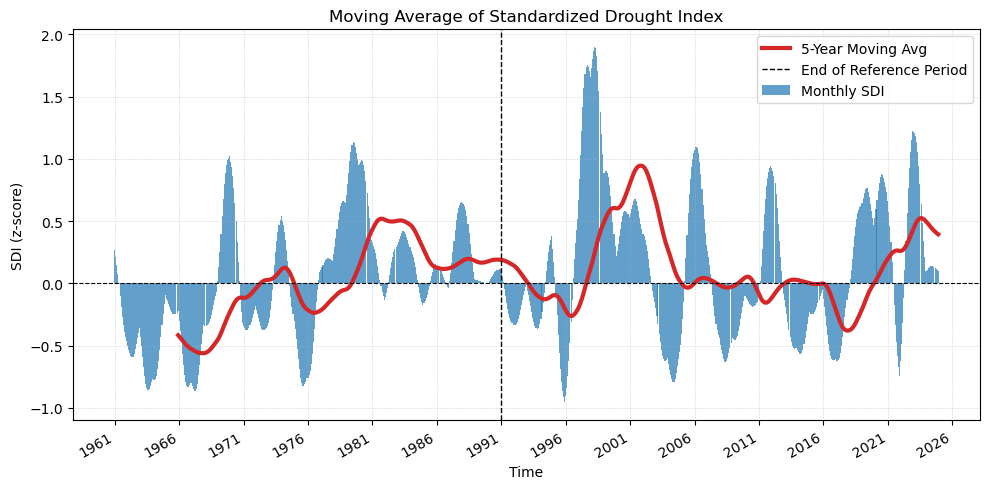

In [53]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# ── 1. Load cleaned Drought Index from disk ───────────────────────────────
da = xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/drought_index.nc")

# ── 2. (If present) collapse over 'step' → 1-D monthly drought series ─────
if "step" in da.dims:
    da = da.mean(dim="step")

# ── 3. Clean to study period and drop NaNs ────────────────────────────────
drought_series = (
    da
    .sel(time=slice("1961-01-01", None))
    .to_series()
    .dropna()
)

# ── 4. Compute right-aligned 60-month rolling mean (full-window only) ─────
rolling_60 = (
    drought_series
    .rolling(window=60, center=False, min_periods=60)
    .mean()
    .dropna()
)

# ── 5. Plot bars + moving average ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# a) Monthly drought index bars
ax.bar(
    drought_series.index,
    drought_series.values,
    width=30,
    color="tab:blue",
    alpha=0.7,
    label="Monthly SDI"
)

# b) 5-year moving average line
ax.plot(
    rolling_60.index,
    rolling_60.values,
    color="tab:red",
    linewidth=3,
    label="5-Year Moving Avg"
)

# ── Add vertical line at end of reference period ──────────────────────────
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(ref_end, color="black", linestyle="--", linewidth=1, label="End of Reference Period")

# ── Cosmetics ─────────────────────────────────────────────────────────────
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Moving Average of Standardized Drought Index")
ax.set_xlabel("Time")
ax.set_ylabel("SDI (z-score)")
ax.grid(True, linestyle=":", linewidth=0.4)
ax.legend()

# ── Custom 5-year x-axis ticks ────────────────────────────────────────────
years = list(range(1961, datetime.datetime.today().year + 2, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.autofmt_xdate()
plt.tight_layout()

# ── Save figure ───────────────────────────────────────────────────────────
fig.savefig("drought_bars_and_moving_avg_fullwindow.png", dpi=300, bbox_inches="tight")
print("✅ Plot saved as drought_bars_and_moving_avg_fullwindow.png")

plt.show()


In [54]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy import stats

# ── 1) Load saved Drought Index ───────────────────────────────────────────
# Script 1 saved a DataArray at this path
da = xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/drought_index.nc")

# Keep study period (1961–… as available)
da = da.sel(time=slice("1961-01-01", None))

# Collapse 'step' if present
if "step" in da.dims:
    da = da.mean(dim="step")

# If any spatial/other dims remain, average them (keep only time)
other_dims = [d for d in da.dims if d != "time"]
if other_dims:
    da = da.mean(dim=other_dims)

# Force load (resolve dask laziness)
da = da.compute()

# ── 2) Convert to pandas Series and drop NaNs ─────────────────────────────
ser = da.to_series().dropna()
n_tot = ser.size

# Handle possible MultiIndex by extracting the time level
if isinstance(ser.index, pd.MultiIndex):
    time_idx = ser.index.get_level_values("time")
else:
    time_idx = ser.index

# ── 3) Descriptive statistics ─────────────────────────────────────────────
desc = ser.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew = ser.skew()
kurt = ser.kurtosis()

# ── 4) Event counts (z-score thresholds; index is standardized) ──────────
# moderate: 1σ < |z| ≤ 2σ
n_mod_pos = ((ser > 1) & (ser <= 2)).sum()
n_mod_neg = ((ser < -1) & (ser >= -2)).sum()
n_mod = n_mod_pos + n_mod_neg

# extreme: |z| > 2σ
n_extreme = ((ser > 2) | (ser < -2)).sum()

# ── 5) Linear trend (OLS) ────────────────────────────────────────────────
years = time_idx.year + (time_idx.dayofyear - 1) / 365.25  # fractional year
slope, intercept, r, p, _ = stats.linregress(years, ser.values)

# ── 6) Print results ─────────────────────────────────────────────────────
print("\n📊 Descriptive statistics for drought_index (country-mean series)")
print(desc.to_string(float_format="%.3f"))
print(f"skewness : {skew:6.3f}")
print(f"kurtosis : {kurt:6.3f}")

print("\n⚠️  Moderate-event frequency (1σ < |z| ≤ 2σ)")
print(f"{n_mod:3d} / {n_tot}   ({n_mod/n_tot:5.1%})")

print("\n🚨  Extreme-event frequency (|z| > 2σ)")
print(f"{n_extreme:3d} / {n_tot}   ({n_extreme/n_tot:5.1%})")

print("\n📈  Linear trend (OLS on standardized drought_index)")
print(f"slope (per year)   : {slope: .4f}")
print(f"slope (per decade) : {slope*10: .4f}")
print(f"R²                 : {r**2: .3f}")
print(f"p-value            : {p: .3e}")



📊 Descriptive statistics for drought_index (country-mean series)
count   768.000
mean      0.073
std       0.563
min      -0.953
5%       -0.757
25%      -0.337
50%       0.012
75%       0.444
95%       1.044
max       1.899
skewness :  0.608
kurtosis :  0.114

⚠️  Moderate-event frequency (1σ < |z| ≤ 2σ)
 45 / 768   ( 5.9%)

🚨  Extreme-event frequency (|z| > 2σ)
  0 / 768   ( 0.0%)

📈  Linear trend (OLS on standardized drought_index)
slope (per year)   :  0.0062
slope (per decade) :  0.0615
R²                 :  0.041
p-value            :  1.591e-08


In [57]:
import os
import time
from typing import Dict
import pandas as pd
import xarray as xr

# ── Start timer ───────────────────────────────────────────────────────────
t0 = time.perf_counter()

# ── Config ────────────────────────────────────────────────────────────────
dir_path = "/Users/coralieroland/ACI-Python/data/composites"
paths: Dict[str, str] = {
    "precipitation": os.path.join(dir_path, "precipitation_index.nc"),
    "t90":           os.path.join(dir_path, "t90_index.nc"),
    "t10":           os.path.join(dir_path, "t10_index.nc"),
    "drought":       os.path.join(dir_path, "drought_index.nc"),
    "wind":          os.path.join(dir_path, "wind_index.nc"),
    "sealevel":      os.path.join(dir_path, "sealevel_index.nc"),
}
factor = 0.024  # sea-level weight

# Fixed monthly grid (1961‑01 → 2024‑12, month‑end timestamps)
full_idx = pd.period_range("1961-01", "2024-12", freq="M").to_timestamp("M")

# ── Helpers ───────────────────────────────────────────────────────────────
def _collapse_to_series(da: xr.DataArray, name: str) -> pd.Series:
    """Collapse non-time dims → mean (skipna), align to full_idx."""
    time_dim = "time" if "time" in da.dims else da.dims[0]
    other_dims = [d for d in da.dims if d != time_dim]
    if other_dims:
        da = da.mean(dim=other_dims, skipna=True)
    s = da.to_series()
    s.index = pd.to_datetime(s.index).to_period("M").to_timestamp("M")
    s = s.reindex(full_idx)
    s.name = name
    return s

def load_component_series(name: str, path: str) -> pd.Series:
    """Open DA/DS robustly and return an aligned monthly Series."""
    if name == "sealevel":
        ds = xr.open_dataset(path)
        da = ds.to_array().mean(dim="variable", skipna=True)  # average stations
    else:
        try:
            da = xr.open_dataarray(path)
        except Exception:
            ds = xr.open_dataset(path)
            da = ds[name] if name in ds.data_vars else next(iter(ds.data_vars.values()))
    return _collapse_to_series(da, name)

# ── Load & align ──────────────────────────────────────────────────────────
comp = {k: load_component_series(k, p) for k, p in paths.items()}
df = pd.DataFrame(comp, index=full_idx)

# ── Compute BACI ──────────────────────────────────────────────────────────
#df["BACI"] = (
    #df["t90"]
    #- df["t10"]
    #+ df["precipitation"]
    #+ df["drought"]
    #+ factor * df["sealevel"]
    #+ df["wind"]
#) / 6.0

# ── Compute BACI ──────────────────────────────────────────────────────────
df["BACI"] = (
    df["t90"]
    - df["t10"]
    + df["precipitation"]
    + df["drought"]
    + factor * df["sealevel"]
) / 5.0

# ── Stats summary ─────────────────────────────────────────────────────────
print("BACI composite calculated successfully! 📊 Stats summary:")
print(f"min:        {df['BACI'].min():.3f}")
print(f"max:        {df['BACI'].max():.3f}")
print(f"mean:       {df['BACI'].mean():.3f}")
print(f"std:        {df['BACI'].std():.3f}")
print(f"count NaNs: {df['BACI'].isnull().sum()}" )

# ── Correlation matrix ────────────────────────────────────────────────────
corr_matrix = df.dropna().corr()
print("\n🔗 Correlation matrix between composites:")
print(corr_matrix.round(3).to_string())

# ── Save NetCDF (atomic, compressed) ──────────────────────────────────────
baci_da = xr.DataArray(df["BACI"].values, coords={"time": full_idx}, dims="time", name="BACI")
baci_ds = xr.Dataset({"BACI": baci_da})

os.makedirs(dir_path, exist_ok=True)
output_nc = os.path.join(dir_path, "BACI_composite.nc")

import tempfile, shutil
fd, tmpname = tempfile.mkstemp(suffix=".nc", dir=dir_path); os.close(fd)
encoding = {"BACI": {"zlib": True, "complevel": 4, "dtype": "float32"}}
baci_ds.to_netcdf(tmpname, engine="netcdf4", encoding=encoding)
shutil.move(tmpname, output_nc)

# ── Timer ─────────────────────────────────────────────────────────────────
t1 = time.perf_counter()
print(f"✅ Saved NetCDF: {output_nc}")
print(f"⏱️ Run time: {t1 - t0:.2f} s")



BACI composite calculated successfully! 📊 Stats summary:
min:        -1.191
max:        1.513
mean:       0.177
std:        0.466
count NaNs: 134

🔗 Correlation matrix between composites:
               precipitation    t90    t10  drought   wind  sealevel   BACI
precipitation          1.000 -0.018 -0.087    0.099  0.376     0.346  0.421
t90                   -0.018  1.000 -0.715    0.122  0.010     0.320  0.815
t10                   -0.087 -0.715  1.000   -0.115 -0.061    -0.412 -0.832
drought                0.099  0.122 -0.115    1.000  0.099     0.242  0.388
wind                   0.376  0.010 -0.061    0.099  1.000     0.319  0.195
sealevel               0.346  0.320 -0.412    0.242  0.319     1.000  0.527
BACI                   0.421  0.815 -0.832    0.388  0.195     0.527  1.000
✅ Saved NetCDF: /Users/coralieroland/ACI-Python/data/composites/BACI_composite.nc
⏱️ Run time: 0.22 s


✅ Plot saved as BACI_bars_and_moving_avg_fullwindow.png


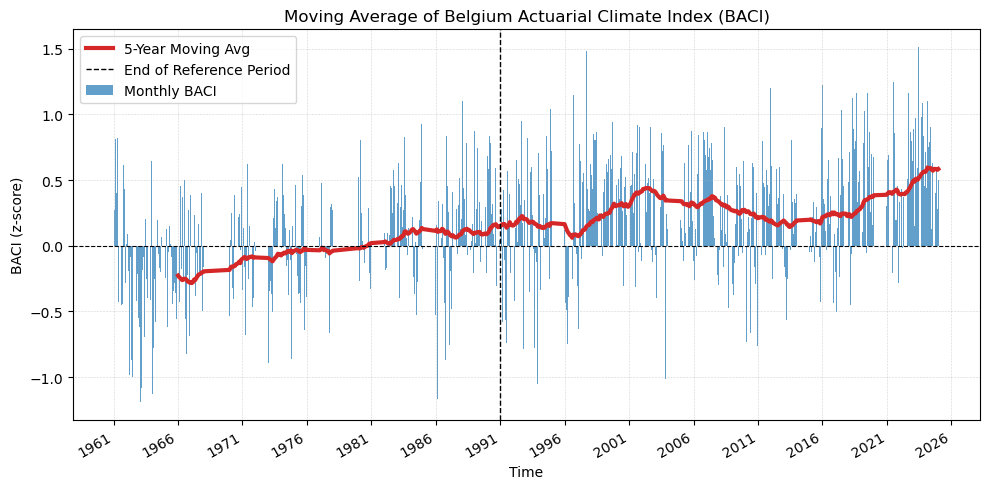

In [58]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import datetime

# ── 1) Load BACI composite ───────────────────────────────────────────────
ds = xr.open_dataset("/Users/coralieroland/ACI-Python/data/composites/BACI_composite.nc")
baci_da = ds["BACI"]

# ── 2) Ensure 1-D monthly BACI series (collapse extra dims if any) ────────
spatial_dims = [d for d in baci_da.dims if d != "time"]
monthly_baci = baci_da.mean(dim=spatial_dims) if spatial_dims else baci_da
if "step" in monthly_baci.dims:
    monthly_baci = monthly_baci.mean(dim="step")

# Keep 1961–end and convert to pandas Series
baci_series = (
    monthly_baci
    .sel(time=slice("1961-01-01", None))
    .to_series()
    .dropna()
)

# ── 3) Right-aligned 60-month rolling mean (full window only) ─────────────
rolling_60 = (
    baci_series
    .rolling(window=60, center=False, min_periods=60)
    .mean()
    .dropna()
)

# ── 4) Plot bars + moving average ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# a) Monthly BACI bars
ax.bar(
    baci_series.index,
    baci_series.values,
    width=25,           # in days
    color="tab:blue",
    alpha=0.7,
    label="Monthly BACI"
)

# b) 5-year moving average line
ax.plot(
    rolling_60.index,
    rolling_60.values,
    color="tab:red",
    linewidth=3,
    label="5-Year Moving Avg"
)

# ── 5) Vertical line at end of reference period ───────────────────────────
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(
    ref_end,
    color="black",
    linestyle="--",
    linewidth=1,
    label="End of Reference Period"
)

# ── 6) Cosmetics ──────────────────────────────────────────────────────────
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Moving Average of Belgium Actuarial Climate Index (BACI)")
ax.set_xlabel("Time")
ax.set_ylabel("BACI (z-score)")
ax.grid(True, linestyle=":", linewidth=0.4)
ax.legend()

# ── 7) Custom 5-year x-axis ticks ─────────────────────────────────────────
years = list(range(1961, datetime.datetime.now().year + 2, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.autofmt_xdate()
plt.tight_layout()

# ── 8) Save figure ────────────────────────────────────────────────────────
fig.savefig("BACI_bars_and_moving_avg_fullwindow.png", dpi=300, bbox_inches="tight")
print("✅ Plot saved as BACI_bars_and_moving_avg_fullwindow.png")

plt.show()


In [59]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy import stats

# ── 1) Load BACI composite ────────────────────────────────────────────────
ds = xr.open_dataset("/Users/coralieroland/ACI-Python/data/composites/BACI_composite.nc")
da = ds["BACI"]  # variable is BACI

# Find time dimension name (should be "time")
time_dim = "time" if "time" in da.dims else (da.dims[0])

# ── 2) Collapse non-time dims (handles 'step', spatial, etc.) ─────────────
other_dims = [d for d in da.dims if d != time_dim]
if other_dims:
    da = da.mean(dim=other_dims)

# Restrict to 1961 onward
da = da.sel({time_dim: slice("1961-01-01", None)})

# Ensure in memory
try:
    da = da.compute()
except Exception:
    pass

# ── 3) Convert to pandas Series and drop NaNs ─────────────────────────────
ser = da.to_series().dropna()
ser.index = pd.to_datetime(ser.index)  # ensure datetime index
n_tot = ser.size

# ── 4) Descriptive statistics ─────────────────────────────────────────────
desc = ser.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew = ser.skew()
kurt = ser.kurtosis()

# ── 5) Event counts ───────────────────────────────────────────────────────
# moderate: 1σ < |BACI| ≤ 2σ
n_mod_pos = ((ser > 1) & (ser <= 2)).sum()
n_mod_neg = ((ser < -1) & (ser >= -2)).sum()
n_mod = n_mod_pos + n_mod_neg

# extreme: |BACI| > 2σ
n_extreme = ((ser > 2) | (ser < -2)).sum()

# ── 6) Linear trend (OLS) ─────────────────────────────────────────────────
years = ser.index.year + (ser.index.dayofyear - 1) / 365.25
slope, intercept, r, p, _ = stats.linregress(years, ser.values)

# ── 7) Print results ──────────────────────────────────────────────────────
print("\n📊 Descriptive statistics for BACI")
print(desc.to_string(float_format="%.3f"))
print(f"skewness : {skew:6.3f}")
print(f"kurtosis : {kurt:6.3f}")

print("\n⚠️  Moderate-event frequency (1σ < |BACI| ≤ 2σ)")
print(f"{n_mod:3d} / {n_tot}   ({n_mod/n_tot:5.1%})")

print("\n🚨  Extreme-event frequency (|BACI| > 2σ)")
print(f"{n_extreme:3d} / {n_tot}   ({n_extreme/n_tot:5.1%})")

print("\n📈  Linear trend (OLS on standardized BACI)")
print(f"slope (per year)   : {slope: .4f}")
print(f"slope (per decade) : {slope*10: .4f}")
print(f"R²                 : {r**2: .3f}")
print(f"p-value            : {p: .3e}")



📊 Descriptive statistics for BACI
count   634.000
mean      0.177
std       0.466
min      -1.191
5%       -0.596
25%      -0.125
50%       0.196
75%       0.500
95%       0.899
max       1.513
skewness : -0.169
kurtosis : -0.134

⚠️  Moderate-event frequency (1σ < |BACI| ≤ 2σ)
 26 / 634   ( 4.1%)

🚨  Extreme-event frequency (|BACI| > 2σ)
  0 / 634   ( 0.0%)

📈  Linear trend (OLS on standardized BACI)
slope (per year)   :  0.0106
slope (per decade) :  0.1063
R²                 :  0.180
p-value            :  5.022e-29


✅ Plot saved as BACIcomponents_bars_and_moving_avg_fullwindow.png


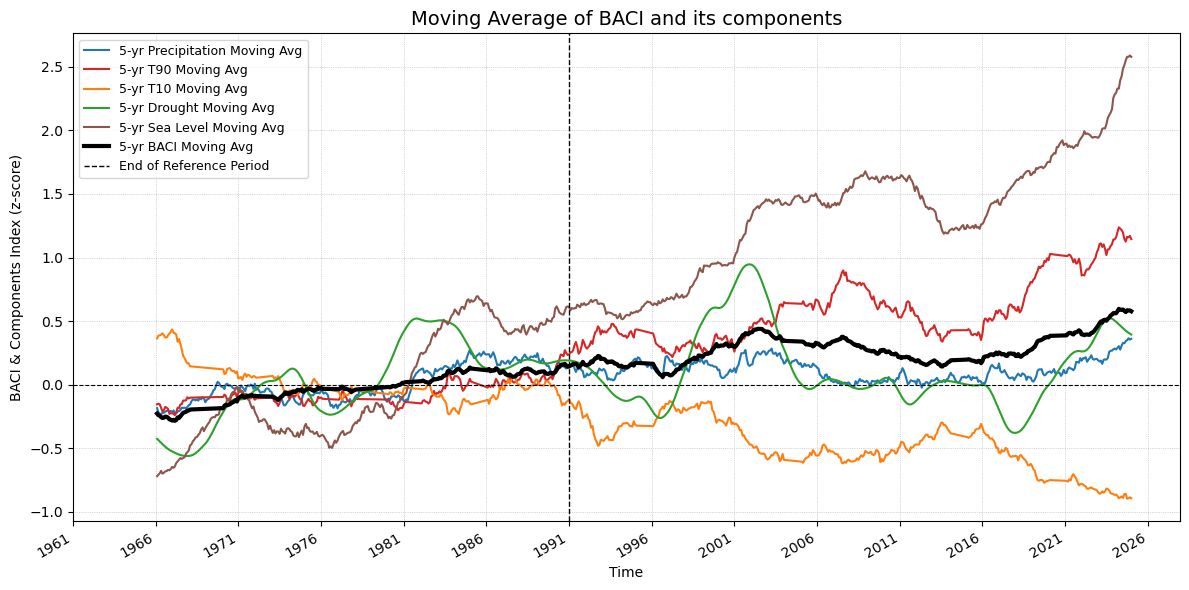

In [64]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

def load_index_series(name, path):
    """
    Load a NetCDF (with one or multiple vars), collapse non-time dims,
    and return a pandas Series indexed at month-end from Jan 1961 onward.
    """
    ds = xr.open_dataset(path)
    # pick the single var, or stack & average if multi-var (e.g. sea level)
    if len(ds.data_vars) == 1:
        da = next(iter(ds.data_vars.values()))
    else:
        da = ds.to_array().mean(dim="variable")
    # collapse any other dims (step, spatial, etc.)
    other_dims = [d for d in da.dims if d != "time"]
    if other_dims:
        da = da.mean(dim=other_dims, skipna=True)
    # slice from 1961-01-01, convert to Series, drop NaNs
    ser = da.sel(time=slice("1961-01-01", None)).to_series().dropna()
    # shift index to month-end
    ser.index = pd.to_datetime(ser.index) + pd.offsets.MonthEnd(1)
    return ser

# ── 1. Define paths ─────────────────────────────────────────────────────────
dir_path = "/Users/coralieroland/ACI-Python/data/composites"
# six components follow the "*_index.nc" naming
components = ["precipitation","t90","t10","drought","sealevel"]
# BACI is stored as "BACI_composite.nc"
paths = {c: f"{dir_path}/{c}_index.nc" for c in components}
paths["BACI"] = f"{dir_path}/BACI_composite.nc"

# ── 2. Load all series ─────────────────────────────────────────────────────
series = {name: load_index_series(name, paths[name]) for name in components + ["BACI"]}

# ── 3. Compute 60-month trailing (right-aligned) rolling means ────────────
rolling = {}
for name, s in series.items():
    roll = s.rolling(window=60, center=False, min_periods=60).mean()
    rolling[name] = roll.dropna()

# Restrict start to first full window (Jan 1966)
for name in rolling:
    rolling[name] = rolling[name].loc["1966-01-01":"2024-12-31"]

# ── 4. Plot everything ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
colors = {
    "precipitation":"tab:blue",
    "t90":"tab:red",
    "t10":"tab:orange",
    "drought":"tab:green",
    "sealevel":"tab:brown",
    "BACI":"black"
}
labels = {
    "precipitation":"Precipitation",
    "t90":"T90",
    "t10":"T10",
    "drought":"Drought",
    "sealevel":"Sea Level",
    "BACI":"BACI"
}

for name, ser in rolling.items():
    lw = 3 if name == "BACI" else 1.5
    ax.plot(
        ser.index,
        ser.values,
        color=colors[name],
        linewidth=lw,
        label=f"5-yr {labels[name]} Moving Avg"
    )

# Reference‐period divider & zero line
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(ref_end, color="black", linestyle="--", linewidth=1, label="End of Reference Period")
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)

# Cosmetics & ticks
ax.set_title("Moving Average of BACI and its components", fontsize=14)
ax.set_xlabel("Time")
ax.set_ylabel("BACI & Components Index (z-score)")
ax.grid(True, linestyle=":", linewidth=0.5)

years = list(range(1961, 2027, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()

# ── Save & show ───────────────────────────────────────────────────────────
fig.savefig("BACIcomponents_bars_and_moving_avg_fullwindow.png", dpi=300, bbox_inches="tight")
print("✅ Plot saved as BACIcomponents_bars_and_moving_avg_fullwindow.png")

plt.show()


🔗 Correlation matrix between composites:
               precipitation    t90    t10  drought   wind  sealevel   BACI
precipitation          1.000 -0.018 -0.087    0.099  0.376     0.346  0.421
t90                   -0.018  1.000 -0.715    0.122  0.010     0.320  0.815
t10                   -0.087 -0.715  1.000   -0.115 -0.061    -0.412 -0.832
drought                0.099  0.122 -0.115    1.000  0.099     0.242  0.388
wind                   0.376  0.010 -0.061    0.099  1.000     0.319  0.195
sealevel               0.346  0.320 -0.412    0.242  0.319     1.000  0.527
BACI                   0.421  0.815 -0.832    0.388  0.195     0.527  1.000
✅ Plot saved as composites_correlation_heatmap.png


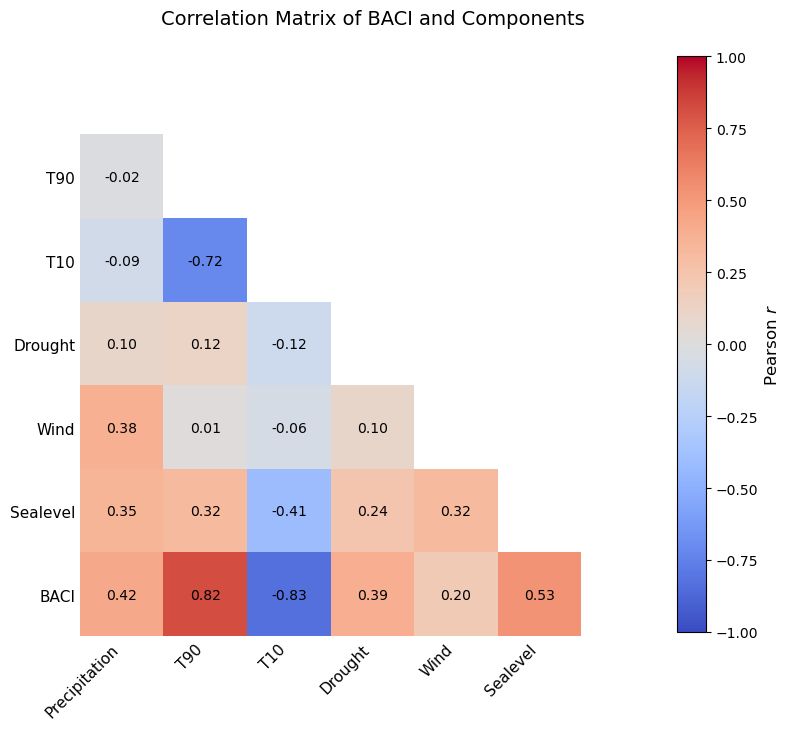


⏱️ Total run time: 2.27 seconds


In [66]:
import os    ### You MUST MODIFY the plot saving path! ###
import time
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Start timer ───────────────────────────────────────────────────────────
t0 = time.perf_counter()

# ── Config ────────────────────────────────────────────────────────────────
dir_path   = "/Users/coralieroland/ACI-Python/data/composites"
components = ["precipitation", "t90", "t10", "drought", "wind", "sealevel", "BACI"]

paths = {c: os.path.join(dir_path, f"{c}_index.nc") for c in components if c != "BACI"}
paths["BACI"] = os.path.join(dir_path, "BACI_composite.nc")

# Fixed monthly grid (1961‑01 → 2024‑12, month‑end timestamps)
full_idx = pd.period_range("1961-01", "2024-12", freq="M").to_timestamp("M")

# ── Helpers ───────────────────────────────────────────────────────────────
def open_var_robust(path: str, preferred: str | None = None) -> xr.DataArray:
    """
    Try to open a NetCDF as a DataArray; fall back to Dataset and pick a variable.
    If 'preferred' is given and present, use it.
    """
    try:
        return xr.open_dataarray(path)
    except Exception:
        ds = xr.open_dataset(path)
        if preferred and preferred in ds.data_vars:
            return ds[preferred]
        if len(ds.data_vars) == 0:
            raise ValueError(f"No data variables in {path}")
        return next(iter(ds.data_vars.values()))

def da_to_series_aligned(da: xr.DataArray) -> pd.Series:
    """Collapse non-time dims → mean (skipna), normalize to month-end (no shift), align to full grid."""
    time_dim = "time" if "time" in da.dims else da.dims[0]
    other_dims = [d for d in da.dims if d != time_dim]
    if other_dims:
        da = da.mean(dim=other_dims, skipna=True)
    s = da.to_series()
    # ✅ month-end without advancing to next month
    s.index = pd.to_datetime(s.index).to_period("M").to_timestamp("M")
    return s.reindex(full_idx)

# ── Load all series (robust) ──────────────────────────────────────────────
series = {}
for c in components:
    path = paths[c]
    if c == "sealevel":
        ds = xr.open_dataset(path)
        da = ds.to_array().mean(dim="variable", skipna=True)  # average stations
    elif c == "BACI":
        da = open_var_robust(path, preferred="BACI")
    else:
        da = open_var_robust(path, preferred=c)
    series[c] = da_to_series_aligned(da).astype("float64")

# ── Merge into a single DataFrame and compute correlation ─────────────────
merged = pd.DataFrame(series, index=full_idx)
corr = merged.dropna().corr()

print("🔗 Correlation matrix between composites:")
print(corr.round(3).to_string())

# ── Prepare labels (rename ACI→BACI already done) ─────────────────────────
labels = corr.columns.tolist()
display_labels = [lbl if lbl == "BACI" else lbl.capitalize() for lbl in labels]

N        = len(labels)
prec_idx = labels.index("precipitation")
baci_idx = labels.index("BACI")

# ── Build mask: diagonal+upper triangle, plus full precipitation row & BACI column ──
mask = np.triu(np.ones((N, N), dtype=bool), k=0)
mask[prec_idx, :] = True
mask[:, baci_idx] = True

# ── Colormap: diverging –1→+1, masked=white ───────────────────────────────
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad("white")
norm = mcolors.Normalize(vmin=-1, vmax=1)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))
masked_data = np.ma.masked_where(mask, corr.values)
im = ax.imshow(masked_data, cmap=cmap, norm=norm, aspect="equal", interpolation="none")

# Annotate only the strictly lower-triangle cells (i > j) that remain
for i in range(N):
    for j in range(i):
        if not mask[i, j]:
            ax.text(j, i, f"{corr.iat[i, j]:.2f}", ha="center", va="center", fontsize=10, color="black")

# Ticks & Tick Labels (blank precipitation row label and BACI column label)
ax.set_xticks(np.arange(N)); ax.set_yticks(np.arange(N))
xtick_labels = ["" if idx == baci_idx else display_labels[idx] for idx in range(N)]
ytick_labels = ["" if idx == prec_idx else display_labels[idx] for idx in range(N)]
ax.set_xticklabels(xtick_labels, rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(ytick_labels, fontsize=11)

# Clean look
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
cbar.set_label("Pearson $r$", fontsize=12)

ax.set_title("Correlation Matrix of BACI and Components", fontsize=14, pad=20)
plt.tight_layout()

# ── Save & show ───────────────────────────────────────────────────────────
fig.savefig("BACI_composites_correlation_heatmap.png", dpi=300, bbox_inches="tight")
print("✅ Plot saved as composites_correlation_heatmap.png")

plt.show()

# ── Timer ─────────────────────────────────────────────────────────────────
t1 = time.perf_counter()
print(f"\n⏱️ Total run time: {t1 - t0:.2f} seconds")
